In [ ]:
import numpy as np
from fig7_through_12_utils import *

🎨 Scientific plotting configuration loaded
   Default save format: png
   Contour levels: 100
   Colormap: bwr


In [2]:
import os
from pathlib import Path
p = os.getcwd() + "/../../"
os.chdir(p)
parent_dir = os.getcwd()

In [3]:
config = {
    "years": np.arange(2019, 2025),
    "common_period": np.arange(2004, 2022),
    "imd_folder": f"{parent_dir}/../monsoon-benchmark_data/imd_rainfall_data/4p0", # Path to ground truth rainfall data (4x4 degrees)
    "thresh_file": f"{parent_dir}/../monsoon-benchmark_data/imd_onset_threshold/mwset4x4.nc4",# Path to threshold for the onset of the monsoon (4x4 degrees)
    "thres_file": f"{parent_dir}/../monsoon-benchmark_data/imd_onset_threshold/mwset4x4.nc4",# Path to threshold for the onset of the monsoon (Alternate naming convention)
    "shpfile_path": f"{parent_dir}/../monsoon-benchmark_data/ind_map_shpfile/india_shapefile.shp",  # Path to Shapefile of India
    "output_dir": f"{parent_dir}/examples/paper_figures/outputs",# Directory to save outputs
    "mok": True,
    "day_bins_30": [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30)],
    "day_bins_15": [(1, 5), (6, 10), (11, 15)],
    "mem_num": 51,
    "date_filter_year": 2024,
    "file_pattern": "{}.nc",
    "data_dir": f"{parent_dir}/../monsoon-benchmark_data/rainfall_4p0",
    "model_paths": {
    "IFS": f"{parent_dir}/../monsoon-benchmark_data/rainfall_4p0/IFS_S2S",  # IFS model
    "AIFS": f"{parent_dir}/../monsoon-benchmark_data/rainfall_4p0/AIFS",  # AIFS model
    "FuXi": f"{parent_dir}/../monsoon-benchmark_data/rainfall_4p0/FuXi",  # FuXi mdoel
    "Graphcast": f"{parent_dir}/../monsoon-benchmark_data/rainfall_4p0/GraphCast",  # Graphcast model
    "GenCast": f"{parent_dir}/../monsoon-benchmark_data/rainfall_4p0/GenCast",  # GenCast model
    "FuXi-S2S": f"{parent_dir}/../monsoon-benchmark_data/rainfall_4p0/FuXi_S2S",  # FuXi_S2S model
    "NGCM": f"{parent_dir}/../monsoon-benchmark_data/rainfall_4p0/NeuralGCM",  # NGCM model
}
}


### Fig 7, 9, 11

Computing climatological onset reference...
Computing climatological onset from 124 years: 1901-2024
Loading IMD rainfall from: /Users/charlieeden/Desktop/Spring 2026/ds_clinic/monsoon-bench/../monsoon-benchmark_data/imd_rainfall_data/4p0/1901.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1901-06-02) as start date for onset detection
Loading IMD rainfall from: /Users/charlieeden/Desktop/Spring 2026/ds_clinic/monsoon-bench/../monsoon-benchmark_data/imd_rainfall_data/4p0/1902.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1902-06-02) as start date for onset detection
Loading IMD rainfall from: /Users/charlieeden/Desktop/Spring 2026/ds_clinic/monsoon-bench/../monsoon-benchmark_data/imd_rainfall_data/4p0/1903.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1903-06-02) as start date for onset detection
Loading IMD rainfall from: /Users/charlieeden/Desktop/Spring 2026/ds_clinic/monsoon-bench/../monsoon-benchmark_data/imd_rainfall_da

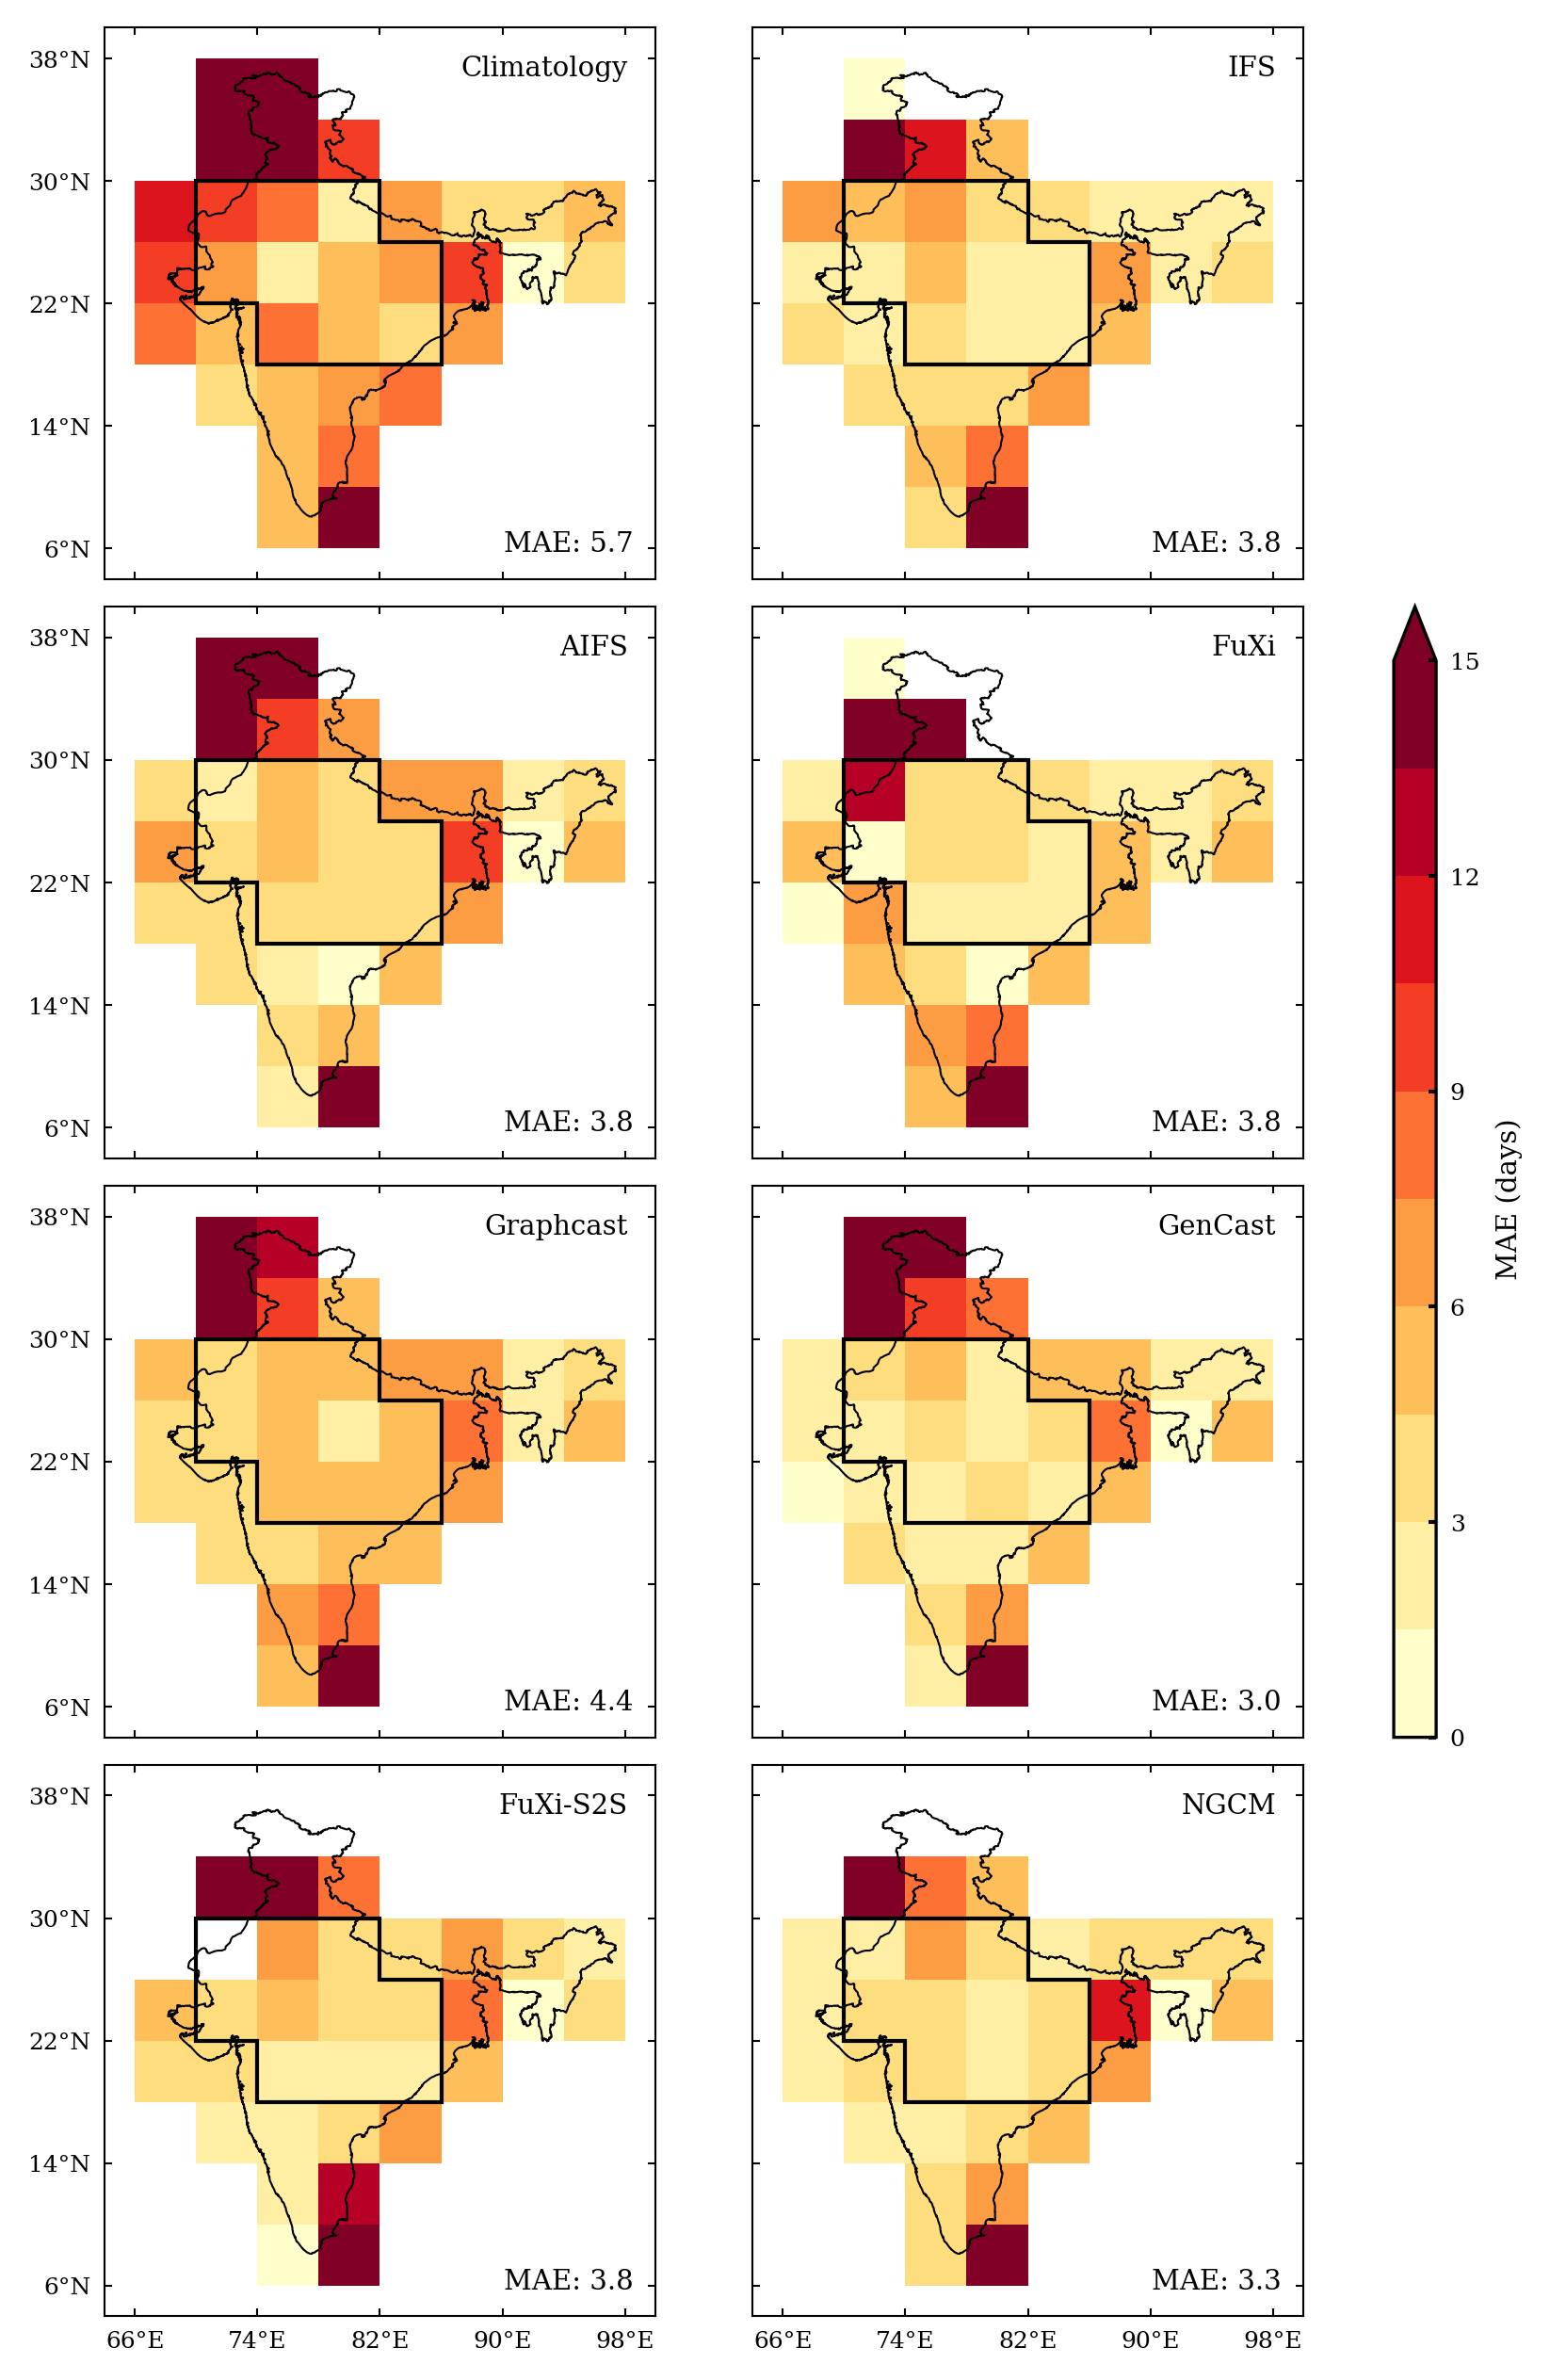

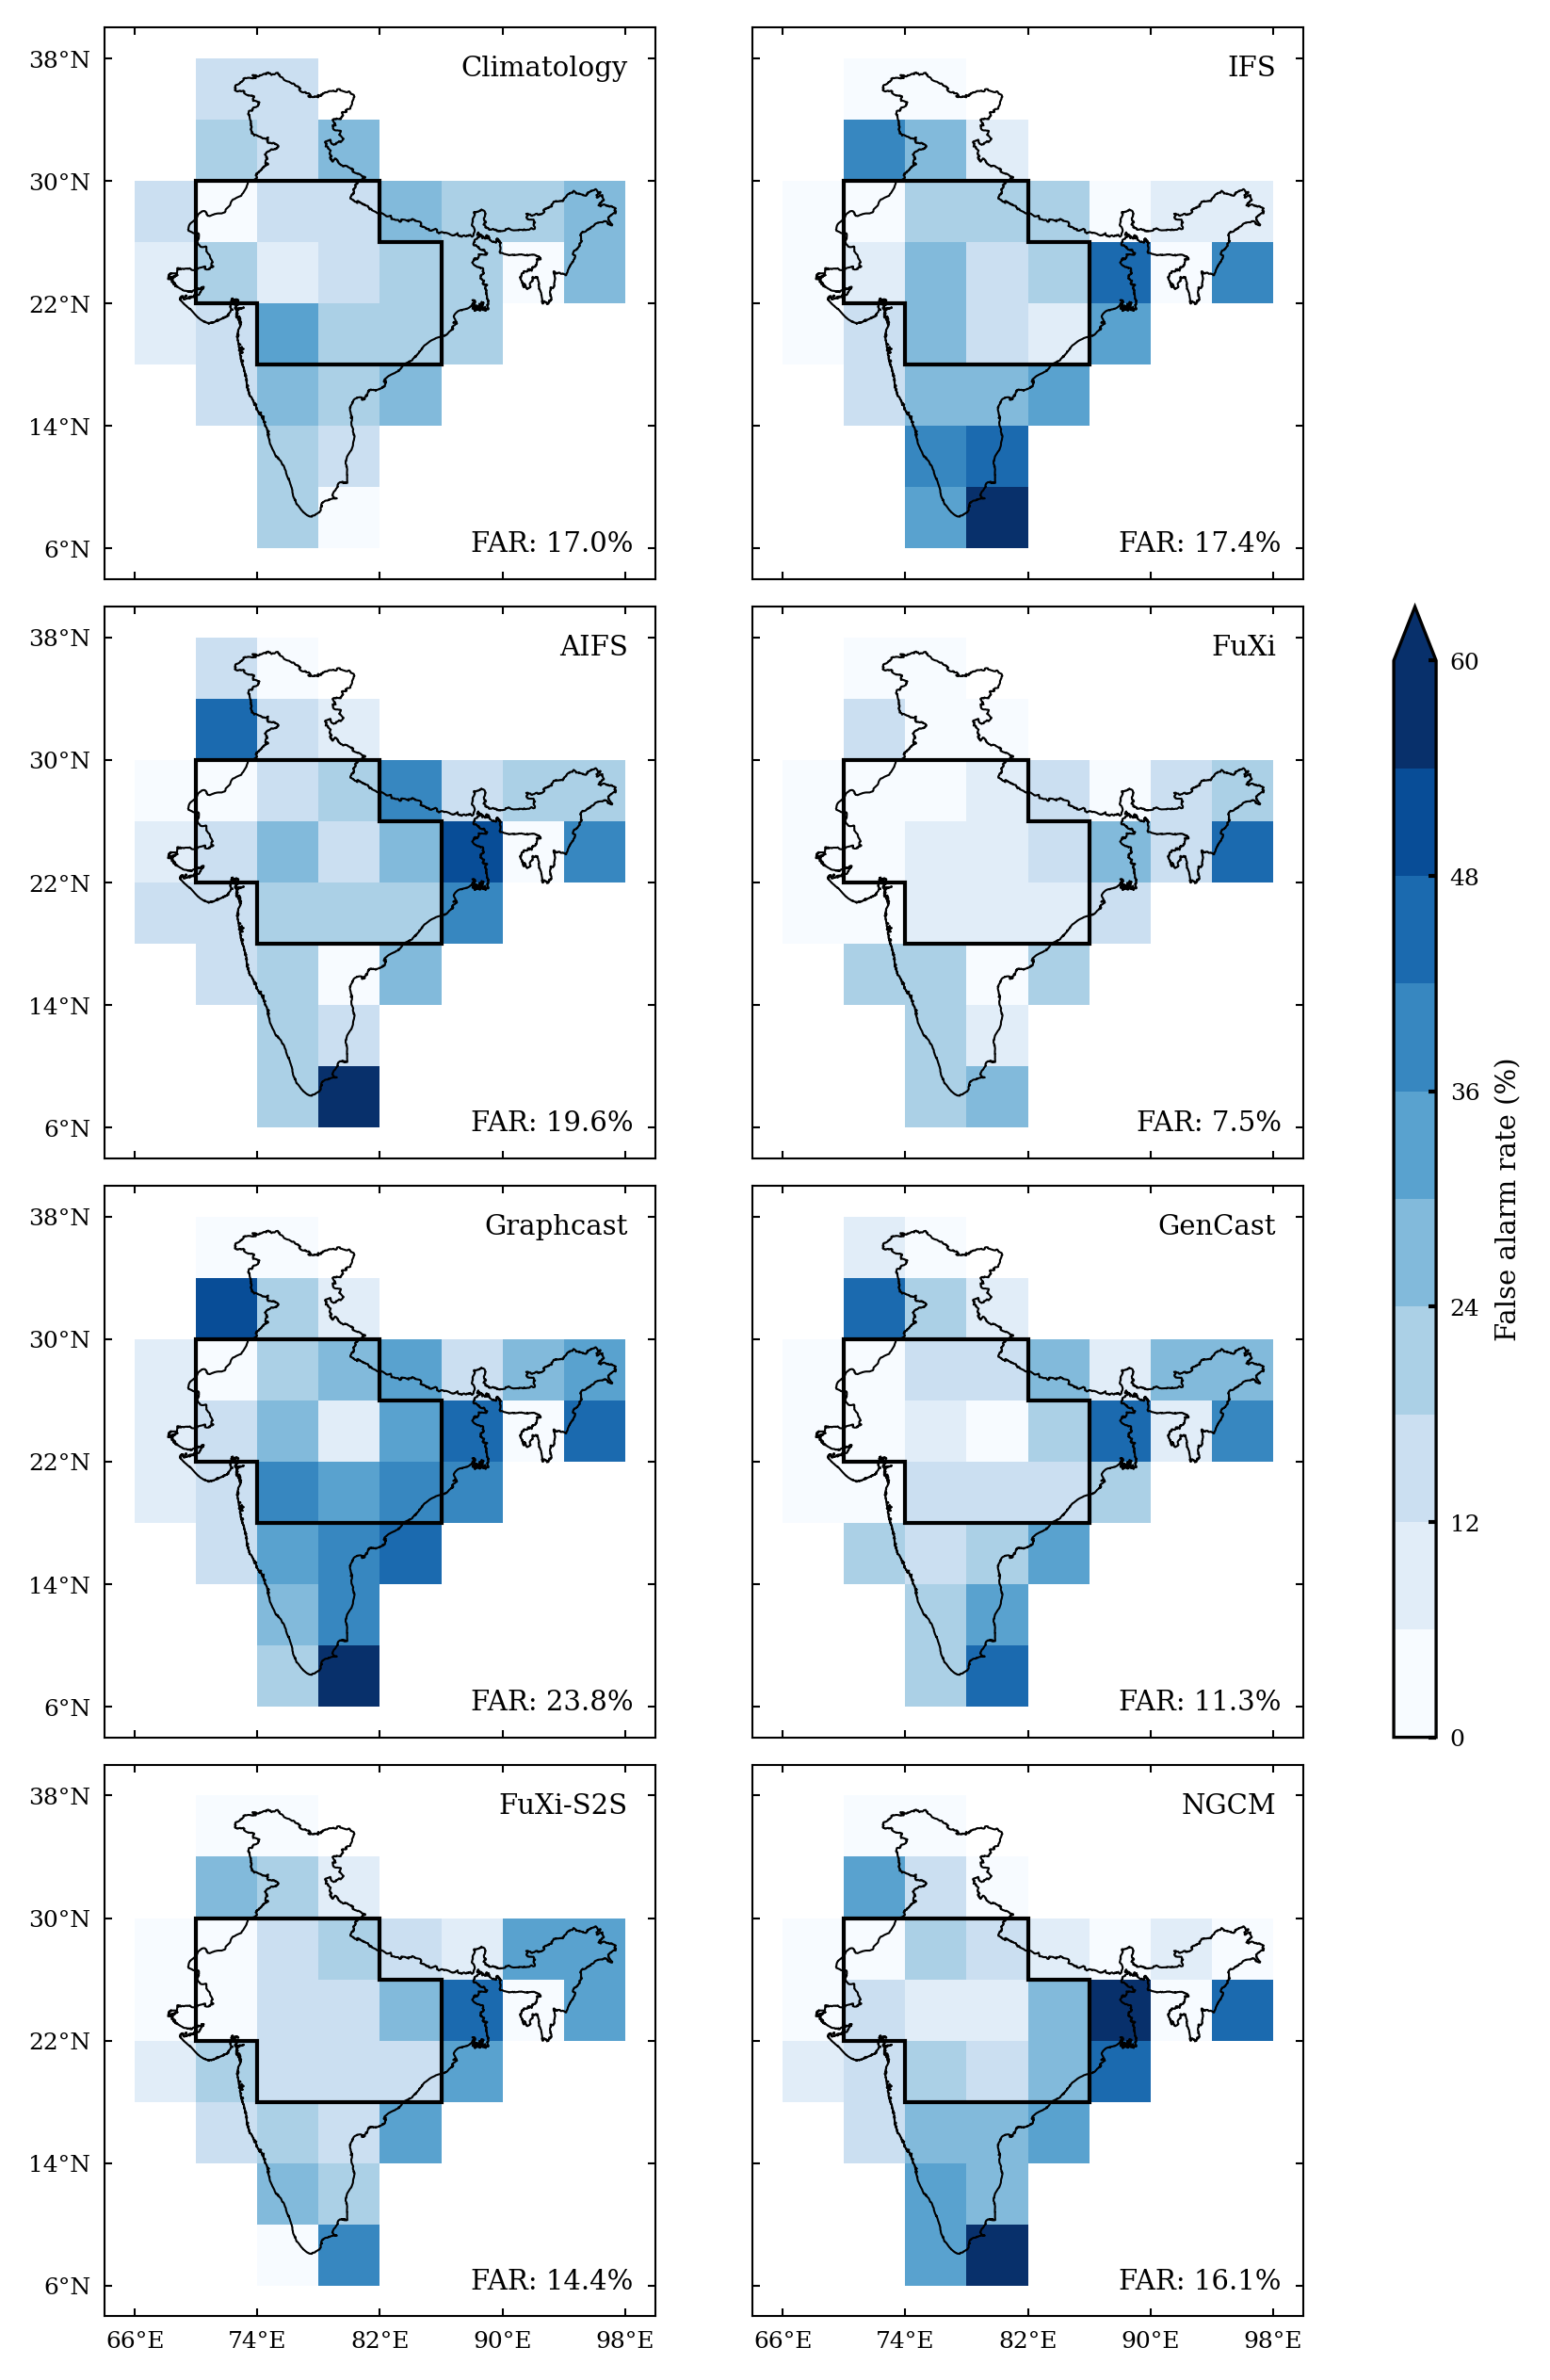

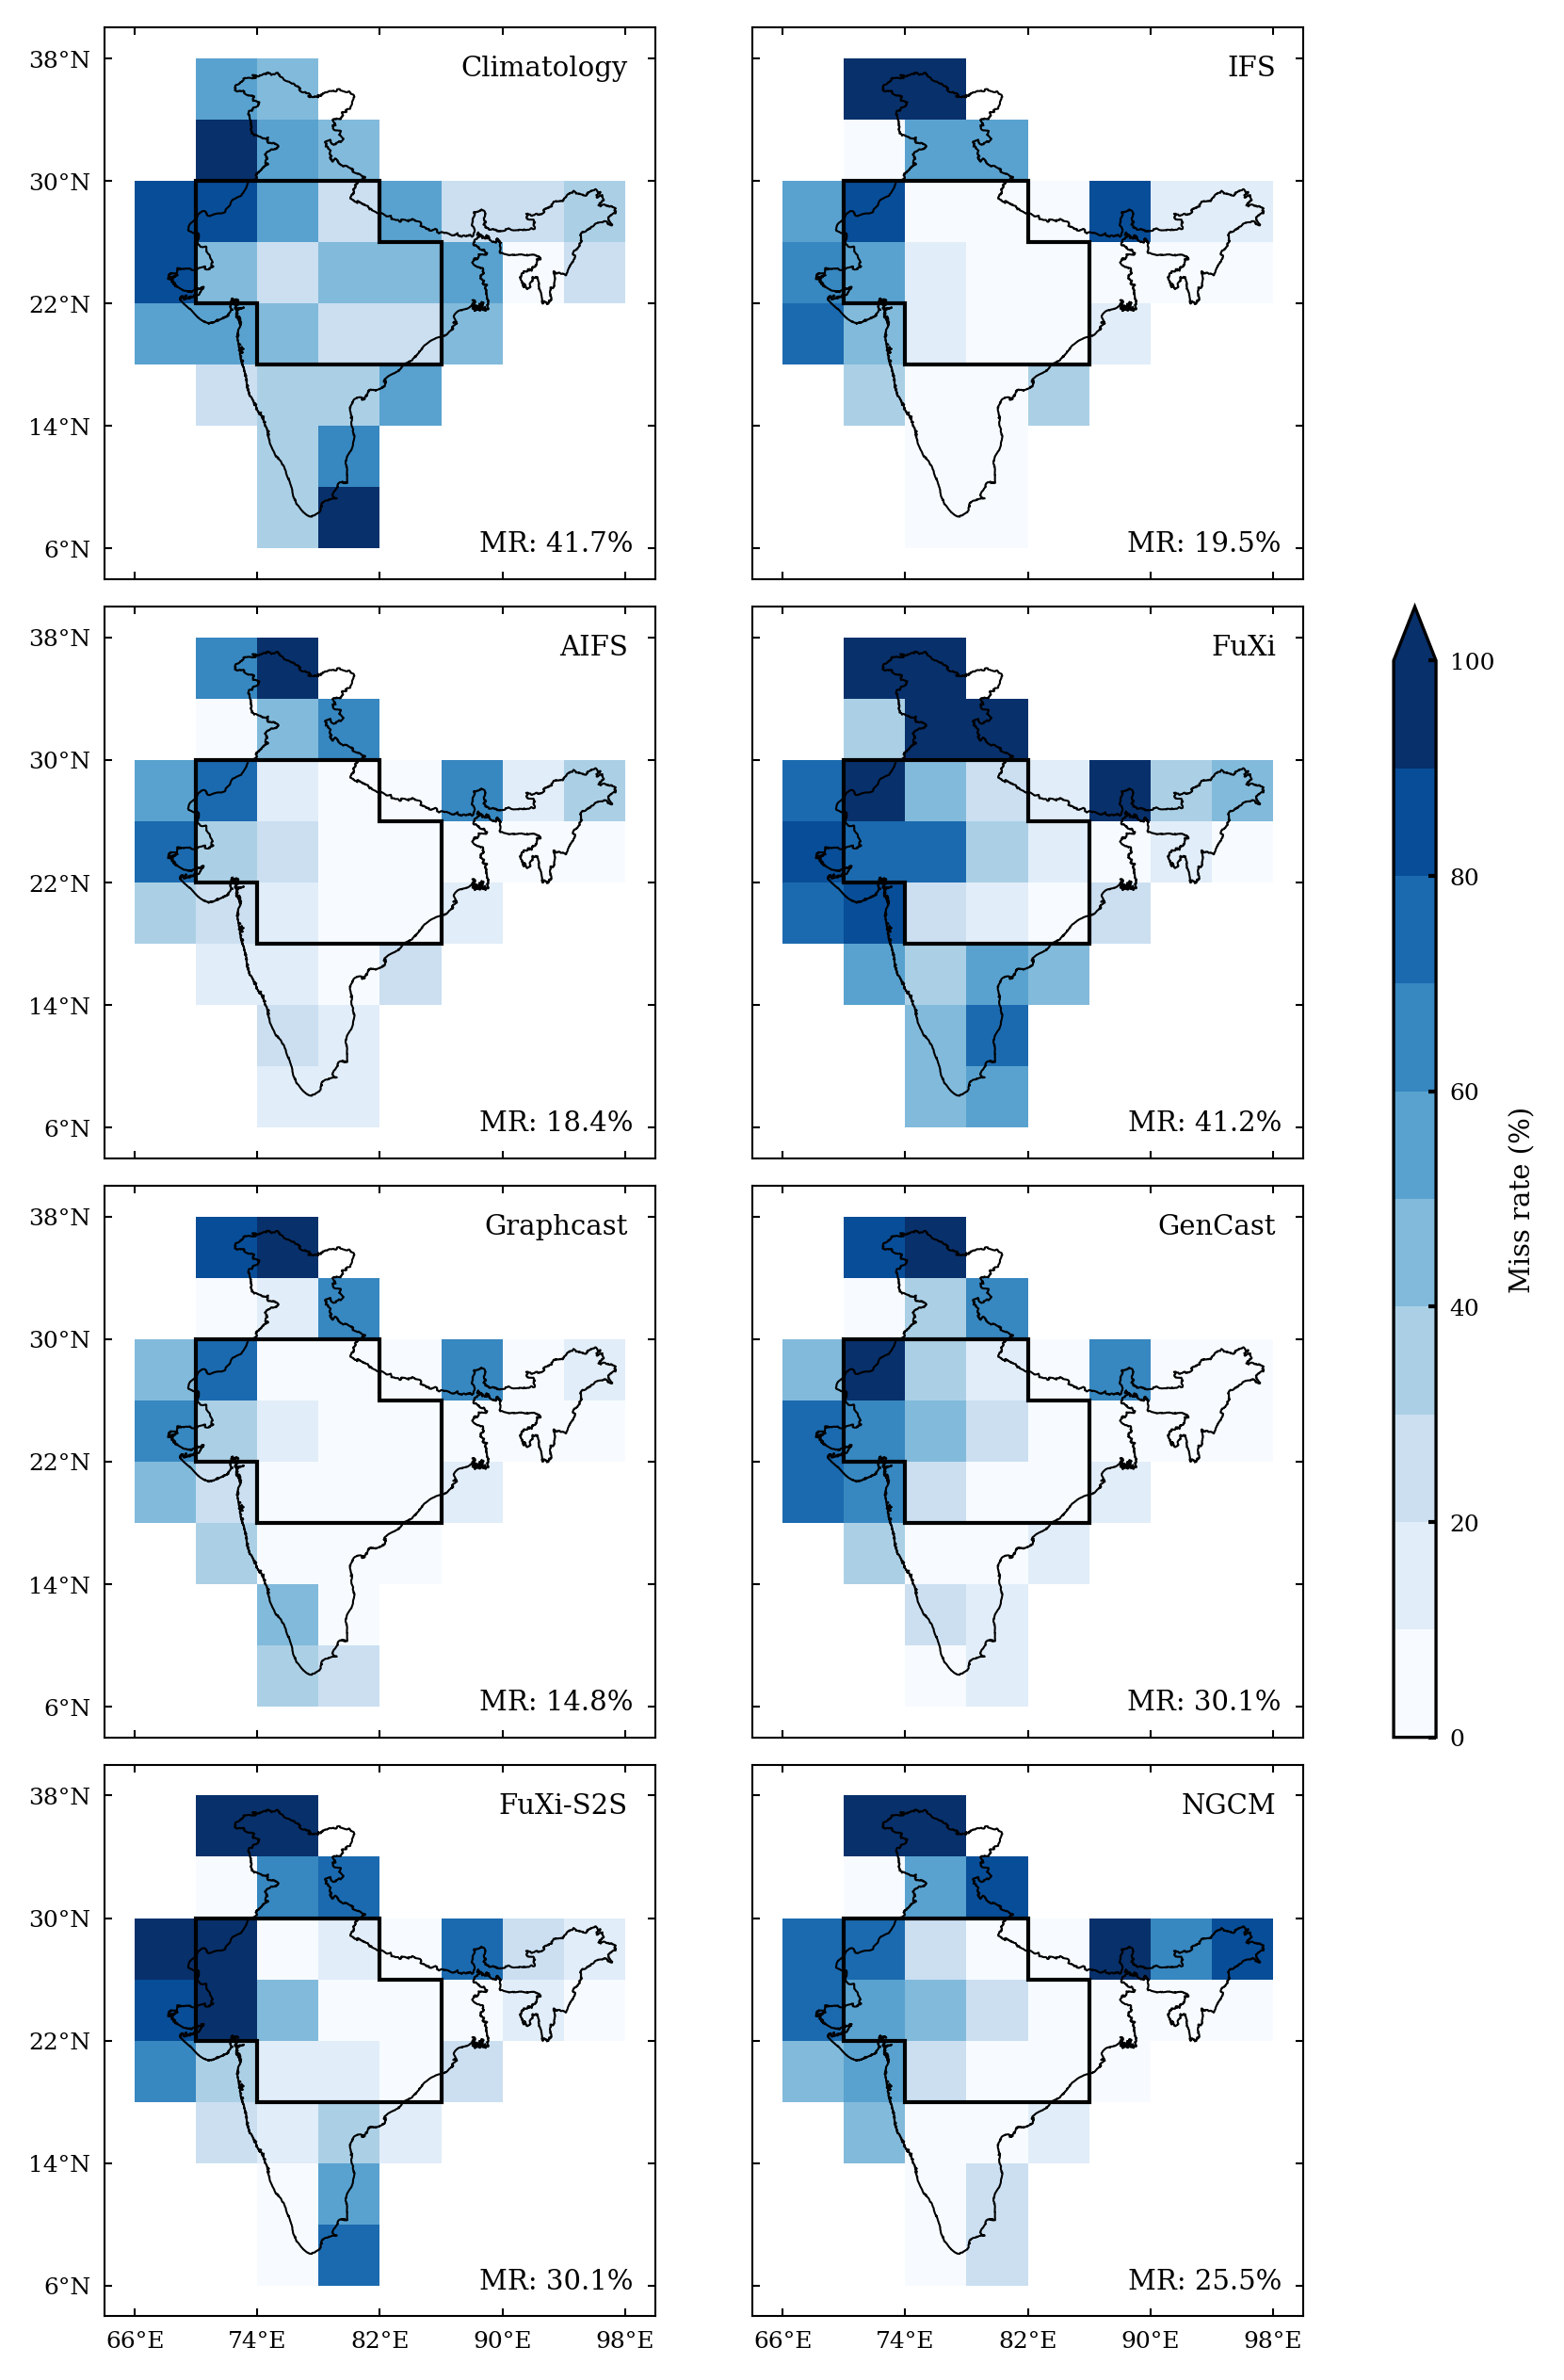

In [ ]:
try:
    (mae_fig7, far_fig7, mr_fig7), gridded_data7 = generate_fig_7_9_11(config=config)
except Exception as e:
    e

### Fig 8, 10, 12

Creating MAE maps for all 8 models in 4x2 layout...
Creating panel 1/8: Climatology
Creating panel 2/8: IFS
Creating panel 3/8: AIFS
Creating panel 4/8: FuXi
Creating panel 5/8: Graphcast
Creating panel 6/8: GenCast
Creating panel 7/8: FuXi-S2S
Creating panel 8/8: NGCM
Creating FAR maps for all 8 models in 4x2 layout...
Creating panel 1/8: Climatology
Creating panel 2/8: IFS
Creating panel 3/8: AIFS
Creating panel 4/8: FuXi
Creating panel 5/8: Graphcast
Creating panel 6/8: GenCast
Creating panel 7/8: FuXi-S2S
Creating panel 8/8: NGCM
Creating MR maps for all 8 models in 4x2 layout...
Creating panel 1/8: Climatology
Creating panel 2/8: IFS
Creating panel 3/8: AIFS
Creating panel 4/8: FuXi
Creating panel 5/8: Graphcast
Creating panel 6/8: GenCast
Creating panel 7/8: FuXi-S2S
Creating panel 8/8: NGCM


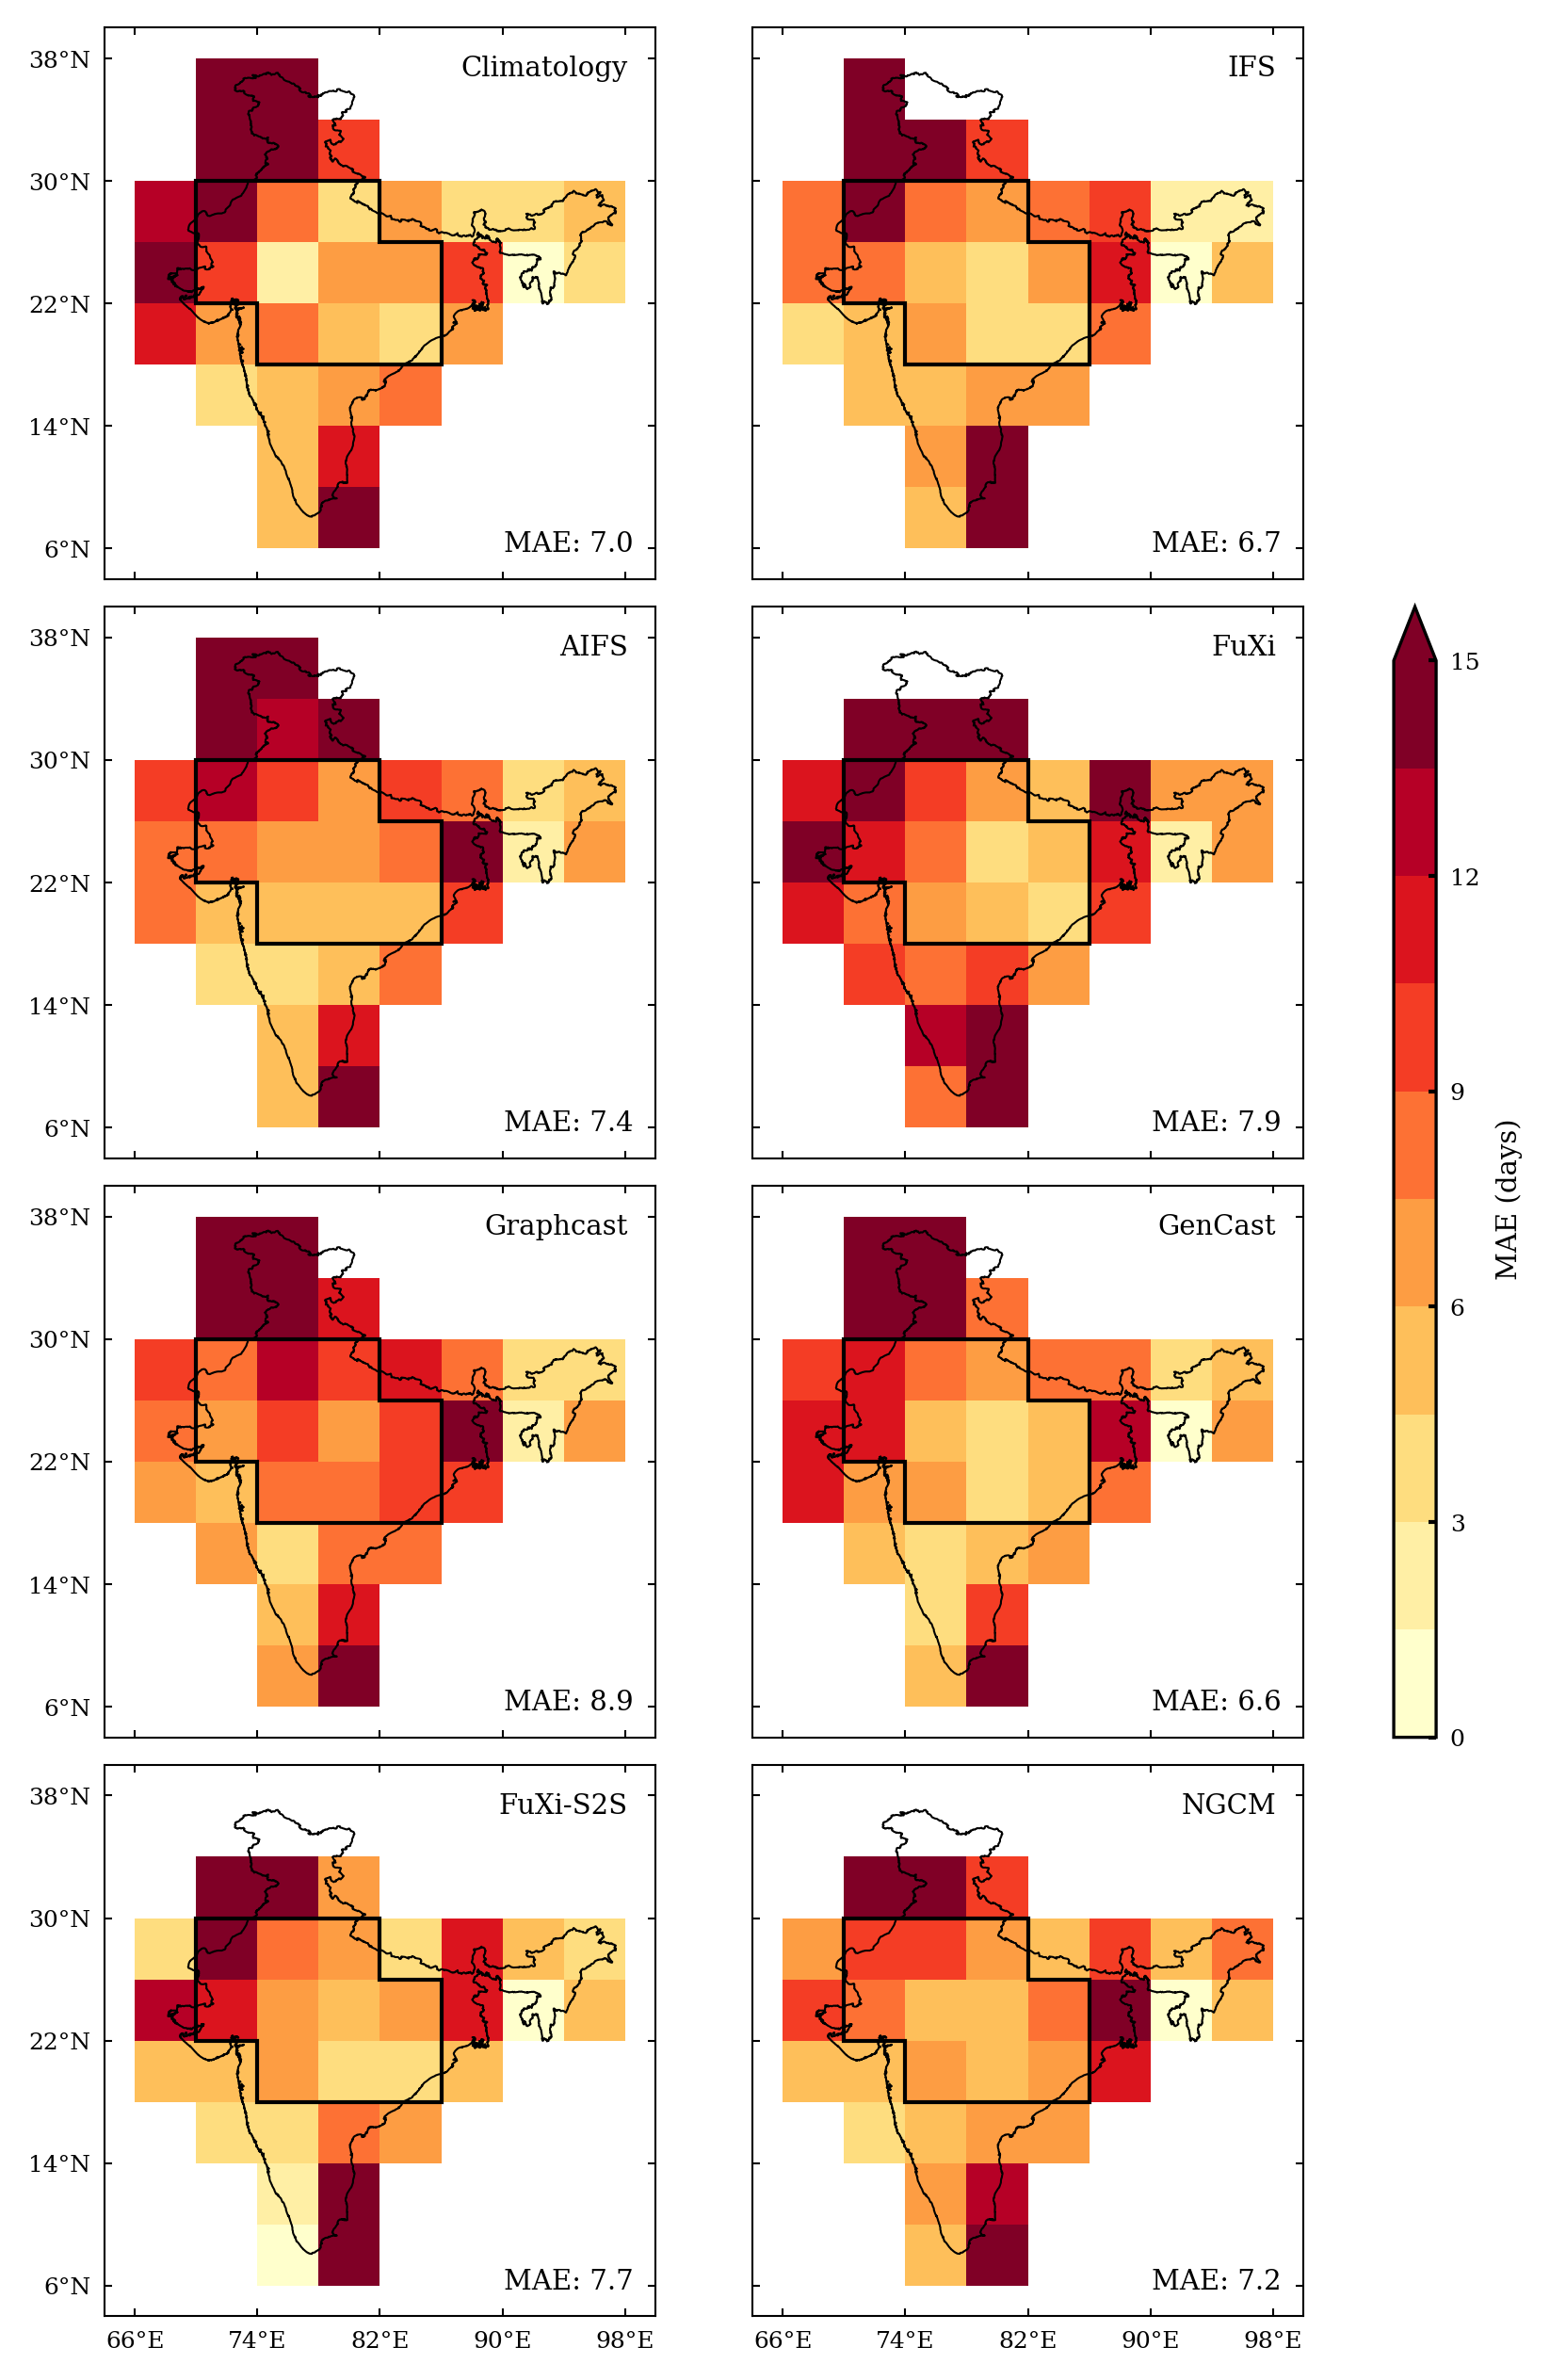

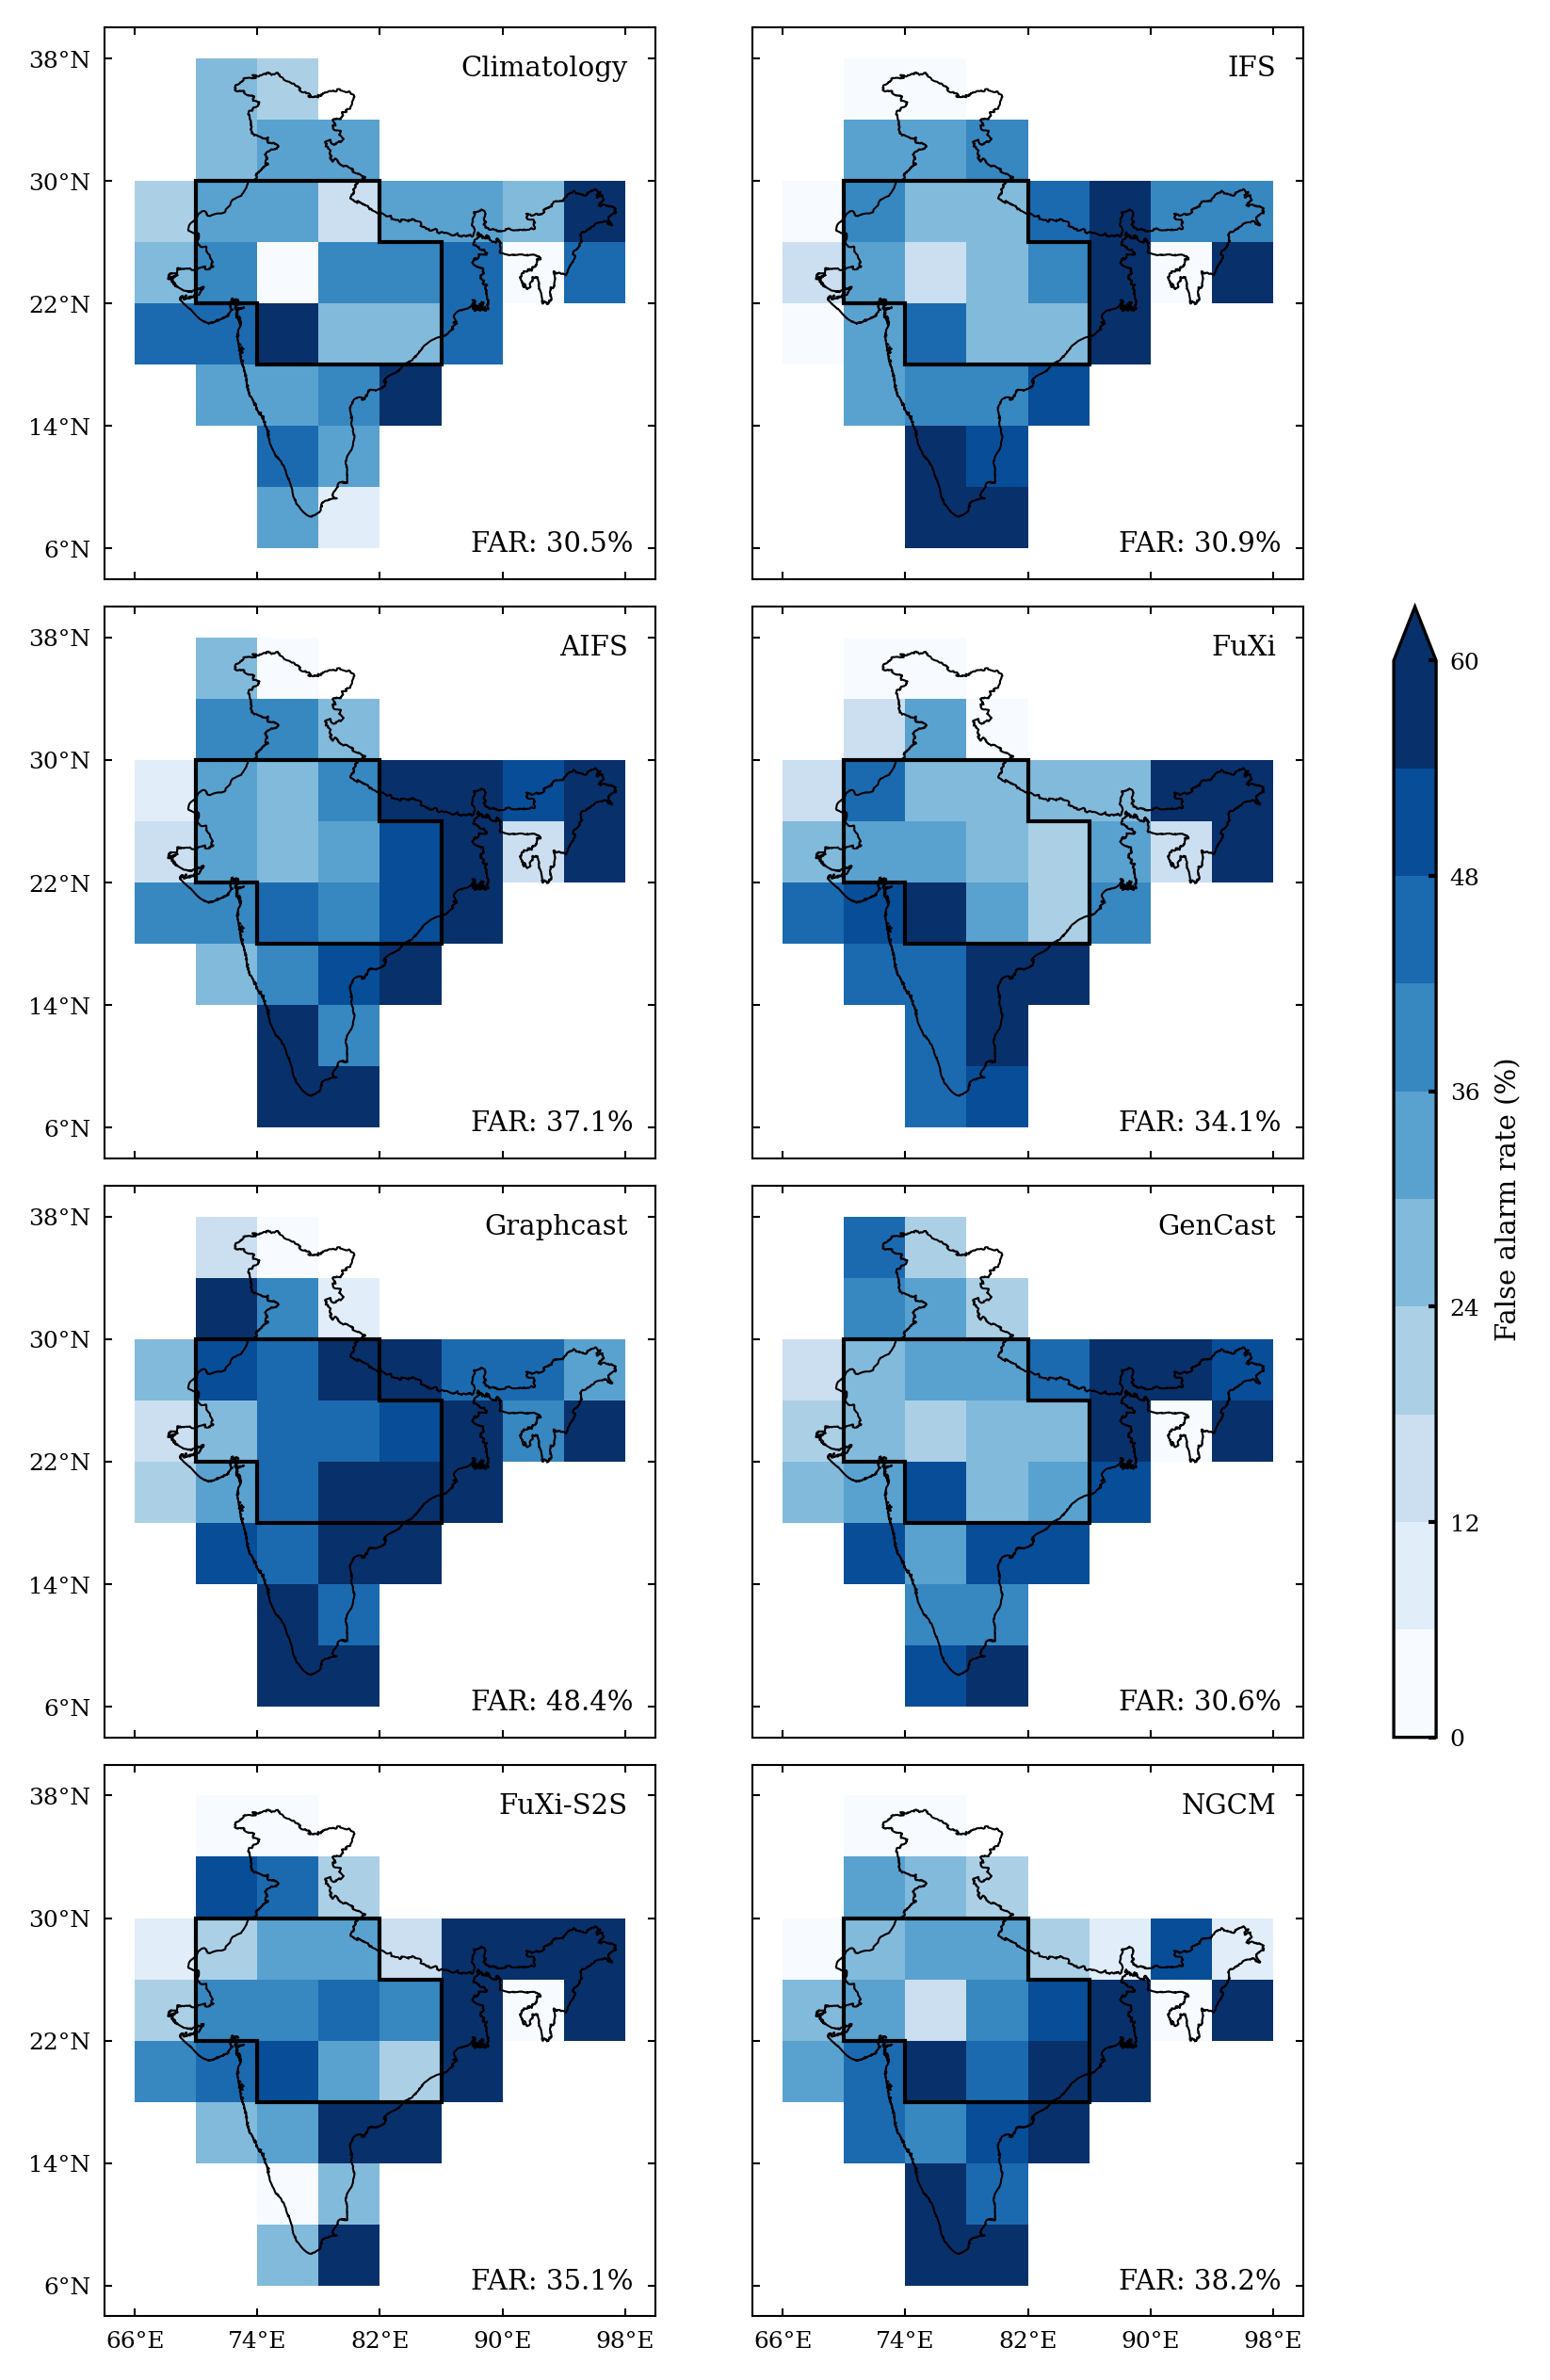

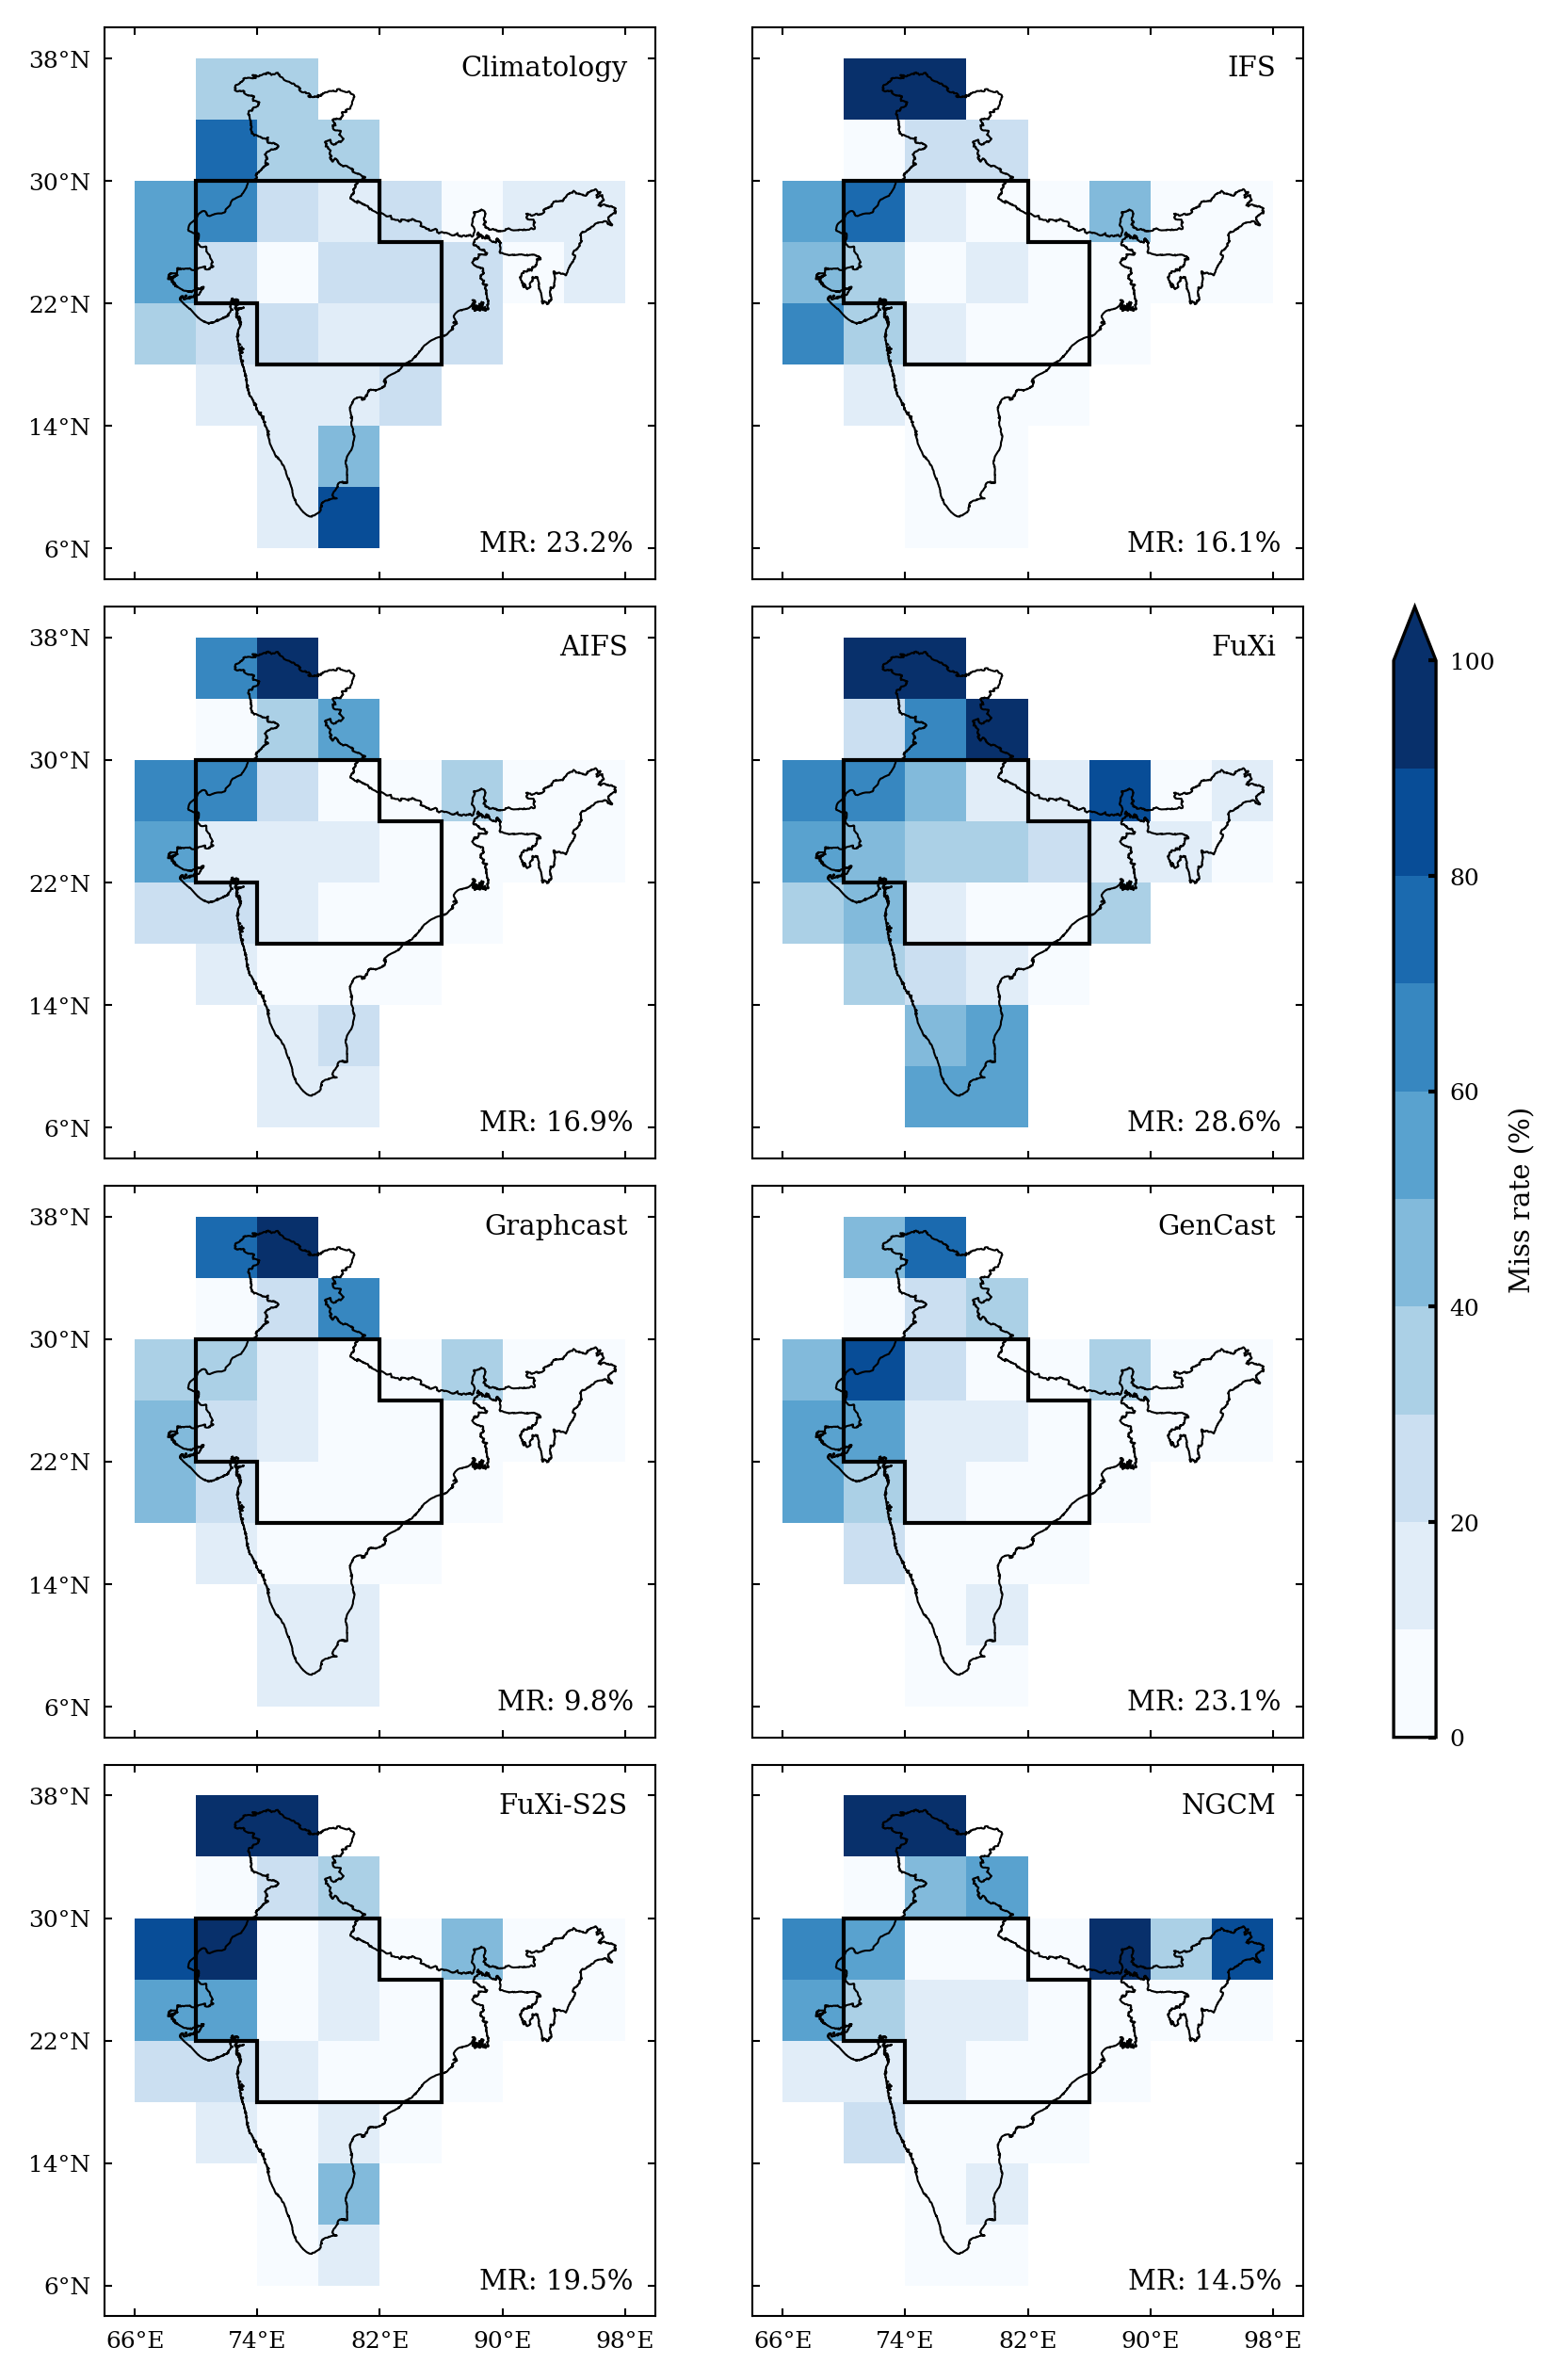

In [ ]:
try:
    (mae_fig10, far_fig10, mr_fig10), gridded_data10 = generate_fig_8_10_12(config=config)
except Exception as e:
    e

### Comparing Recreated Grids to Paper Grids

#### Spatial Metrics

In [ ]:
# Load data from MAT files
import scipy.io as sio
# Define file paths
file_15day = '/Users/charlieeden/Downloads/mae_far_mr_15_day_2019_2024 (1).mat'
file_30day = '/Users/charlieeden/Downloads/mae_far_mr_16_30_day_2019_2024 (1).mat'
print("Loading data...")
data_15 = sio.loadmat(file_15day)
data_30 = sio.loadmat(file_30day)

    
    # Extract coordinate data (assuming they're in the MAT files)
    # Check what variables are available in the MAT files
print("Available variables in 15-day file:", [key for key in data_15.keys() if not key.startswith('__')])
print("Available variables in 30-day file:", [key for key in data_30.keys() if not key.startswith('__')])

    # Extract coordinates - adjust variable names as needed based on your MAT file structure
if 'lon' in data_15:
    lon = data_15['lon'].flatten()
    lat = data_15['lat'].flatten()
    lons = data_15['lon'].flatten()
    lats = data_15['lat'].flatten()
else:
    # If coordinates not found, use default range - you may need to adjust this
    print("Warning: Coordinates not found in MAT file, using default range")
    lon = np.arange(70, 101, 4)
    lat = np.arange(8, 39, 4)

    # Extract MAE data - adjust variable names as needed

mae_avg15 = data_15['mae_avg']
mae_cmz15 = data_15['mae_cmz_mean']
std_er15 = data_15['std_er']
far15 = data_15['false_alarm']
far_cmz15 = data_15['far_cmz_mean']
mr15 = data_15['miss_rate']
mr_cmz15 = data_15['mr_cmz_mean']



mae_avg30 = data_30['mae_avg']
mae_cmz30 = data_30['mae_cmz_mean']
std_er30 = data_30['std_er']
far30 = data_30['false_alarm']
far_cmz30 = data_30['far_cmz_mean']
mr30 = data_30['miss_rate']
mr_cmz30 = data_30['mr_cmz_mean']

Loading data...


Available variables in 15-day file: ['csi_cmz_mean', 'csi_yr', 'ets_cmz_mean', 'ets_yr', 'false_alarm', 'far_cmz_mean', 'lat', 'lon', 'mae_avg', 'mae_cmz_mean', 'miss_rate', 'model_str', 'mr_cmz_mean', 'std_er']
Available variables in 30-day file: ['csi_cmz_mean', 'csi_yr', 'ets_cmz_mean', 'ets_yr', 'false_alarm', 'far_cmz_mean', 'lat', 'lon', 'mae_avg', 'mae_cmz_mean', 'miss_rate', 'model_str', 'mr_cmz_mean', 'std_er']


In [ ]:
def package_gridded_data(mae, far, mr, lat, lon, models):
    """
    Convert (lat, lon, model) arrays into compare_grids format.
    """
    n_models = len(models) # <-- FIX

    return {
        "mae": [mae[:, :, i].T for i in range(n_models)],
        "far": [far[:, :, i].T * 100 for i in range(n_models)],
        "mr":  [mr[:, :, i].T * 100 for i in range(n_models)],
        "lat": lat,
        "lon": lon
    }

def compare_grids(paper_grid, recreated_grid):
    out = { "mae": [], "far": [], "mr": [], "lat": lat, "lon": lon }
    for metric in paper_grid.keys():
        if metric != "lat" and metric != "lon":
            for ind, d_array in enumerate(paper_grid[metric]):
                diff = d_array - recreated_grid[metric][ind]
                out[metric].append(diff)
                
    return out

In [ ]:
model_str = ['Climatology', 'IFS', 'AIFS', 'FuXi', 'Graphcast', 'GenCast', 'FuXi-S2S', 'NGCM']

fig_7_9_11_grid = package_gridded_data(
    mae=mae_avg15,
    far=far15,
    mr=mr15,
    lat=lat,
    lon=lon,
    models=model_str
)

fig_8_10_12_grid = package_gridded_data(
    mae=mae_avg30,
    far=far30,
    mr=mr30,
    lat=lat,
    lon=lon,
    models=model_str
)

In [ ]:
differences_fig_7_9_11 = compare_grids(fig_7_9_11_grid, gridded_data7)

In [ ]:
differences_fig_8_10_12 = compare_grids(fig_8_10_12_grid, gridded_data10)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
from matplotlib.gridspec import GridSpec
from monsoonbench.spatial.regions import get_india_outline


def create_8_panel_diff_figure(
    diff_dict,
    lon,
    lat,
    models,
    metric="mae",
    cmap="RdBu_r",
    symmetric=True
):
    """
    8-panel (4x2) difference map for a SINGLE metric.
    """

    grids = diff_dict[metric]
    n_models = len(grids)

    if n_models != 8:
        print(f"Warning: expected 8 models, got {n_models}")

    # Slightly taller figure = prevents crowding
    fig = plt.figure(figsize=(6, 10), dpi=300)

    gs = GridSpec(
        4, 3, figure=fig,
        hspace=0.28,   # FIXED (prevents title overlap)
        wspace=-0.2,
        left=0.05, right=0.85, top=0.95, bottom=0.05,
        width_ratios=[1, 1, 0.08]
    )

    # --- create 8 axes ---
    axes = []
    for row in range(4):
        for col in range(2):
            ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())
            axes.append(ax)

    print(f"Creating {metric.upper()} diff figure...")

    # --- shared color scaling ---
    all_vals = np.concatenate([g.values.flatten() for g in grids])
    all_vals = all_vals[~np.isnan(all_vals)]

    if symmetric:
        abs_vals = np.abs(all_vals)
        nonzero_vals = abs_vals[(abs_vals > 1e-6) & (abs_vals <= 100)]  # valid % range
    
    if len(nonzero_vals) > 0:
        vmax = np.nanpercentile(nonzero_vals, 95)
    else:
        vmax = 1.0  # fallback if truly all zero
    
    vmin = -vmax

    images = []

    # --- plot panels ---
    for i in range(8):
        ax = axes[i]
        diff = grids[i]

        print(f"Panel {i+1}/8: {metric} - {models[i]}")

        im = ax.pcolormesh(
            lon,
            lat,
            diff,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            transform=ccrs.PlateCarree()
        )
        for j in range(len(lat)):
            for k in range(len(lon)):
                val = diff.values[j, k]
                if np.isnan(val):
                    continue
                text_color = 'black' if -0.1 <= val <= 0.1 else 'white'
                ax.text(
                    lon[k], lat[j], f'{val:.2f}',
                    color=text_color,
                    fontsize=3,
                    ha='center', va='center',
                    transform=ccrs.PlateCarree()
                )

        india_boundaries = get_india_outline(config["shpfile_path"])
        for boundary in india_boundaries:
            india_lon, india_lat = boundary
            ax.plot(india_lon, india_lat, color='black', linewidth=map_lw)

        # FIXED: add padding so titles don't collide
        ax.set_title(models[i], fontsize=7, pad=8)

        ax.set_xlim([lon[0]-4, 100])
        ax.set_ylim([lat[0]-4, lat[-1]+4])

        yticks = np.arange(lat[0]-2, lat[-1]+3, 8)
        yticklabels = [f"{int(y)}°N" if i % 1 == 0 else "" for i, y in enumerate(yticks)]
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels)

        ax.set_aspect("equal", adjustable="box")
        # ax.set_extent(
        #     [lon.min(), lon.max(), lat.min(), lat.max()],
        #     crs=ccrs.PlateCarree()
        # )
        xticks = np.arange(lon[0]-2, lon[-1]+3, 8)
        xticklabels = [f"{int(x)}°E" if i % 1 == 0 else "" for i, x in enumerate(xticks)]
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels)

        ax.grid(False)



        images.append(im)

    # --- colorbar spanning middle rows ---
    row2_ax = axes[2]
    row3_ax = axes[5]

    row2_pos = row2_ax.get_position()
    row3_pos = row3_ax.get_position()

    colorbar_height = row2_pos.y1 - row3_pos.y0
    colorbar_y_start = row3_pos.y0

    cax = fig.add_axes([
        0.87,
        colorbar_y_start,
        0.025,
        colorbar_height
    ])

    cbar = fig.colorbar(images[0], cax=cax, orientation='vertical')
    cbar.set_label(f"{metric.upper()} difference")

    cbar.ax.tick_params(length=2, width=1)
    cbar.ax.minorticks_off()

    plt.tight_layout()

    # filename = f"fig_{metric}_diff_8panel.pdf"
    # filename2 = f"fig_{metric}_diff_8panel.png"

    # plt.savefig(filename, dpi=600, bbox_inches="tight")
    # plt.savefig(filename2, dpi=600, bbox_inches="tight")

    # print(f"Saved: {filename}")

    return fig

Creating MAE diff figure...
Panel 1/8: mae - Climatology
Panel 2/8: mae - IFS
Panel 3/8: mae - AIFS
Panel 4/8: mae - FuXi
Panel 5/8: mae - Graphcast
Panel 6/8: mae - GenCast
Panel 7/8: mae - FuXi-S2S
Panel 8/8: mae - NGCM


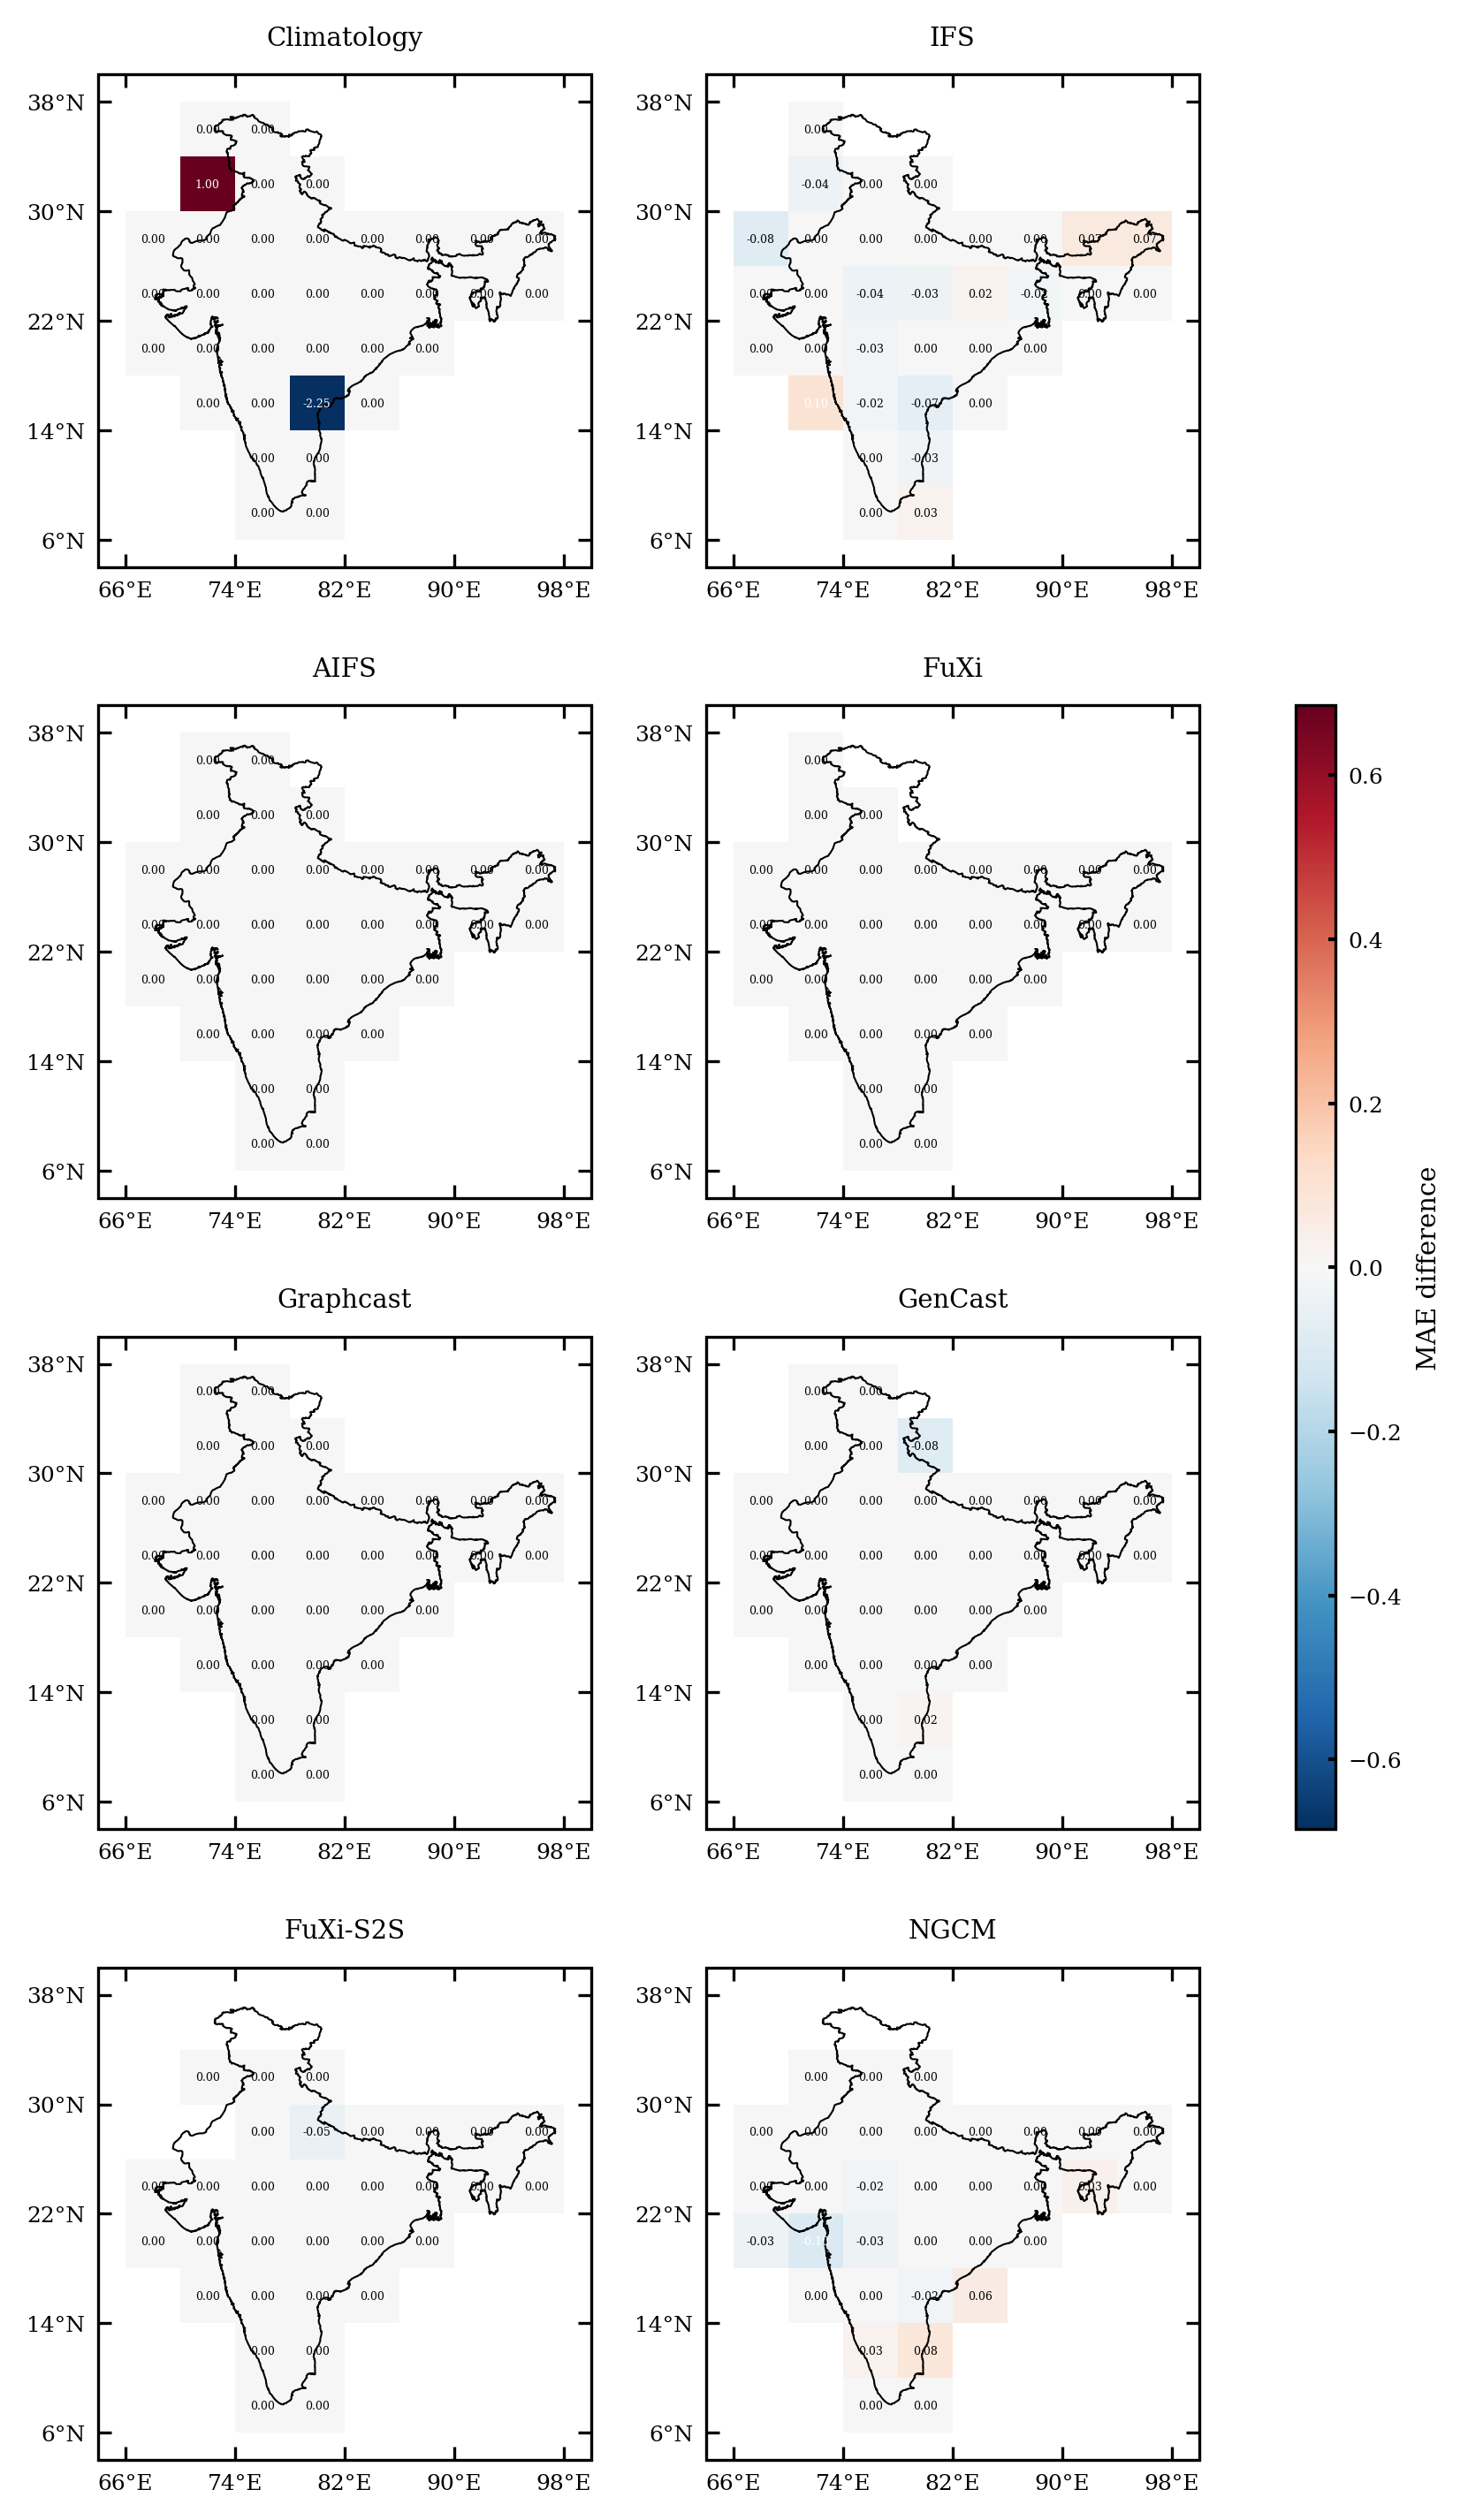

In [ ]:
spatial_15_diffs_mae_fig = create_8_panel_diff_figure(
    differences_fig_7_9_11,
    lon=lon,
    lat=lat,
    models=model_str,
    metric="mae"
)

Creating MAE diff figure...
Panel 1/8: mae - Climatology
Panel 2/8: mae - IFS
Panel 3/8: mae - AIFS
Panel 4/8: mae - FuXi
Panel 5/8: mae - Graphcast
Panel 6/8: mae - GenCast
Panel 7/8: mae - FuXi-S2S
Panel 8/8: mae - NGCM


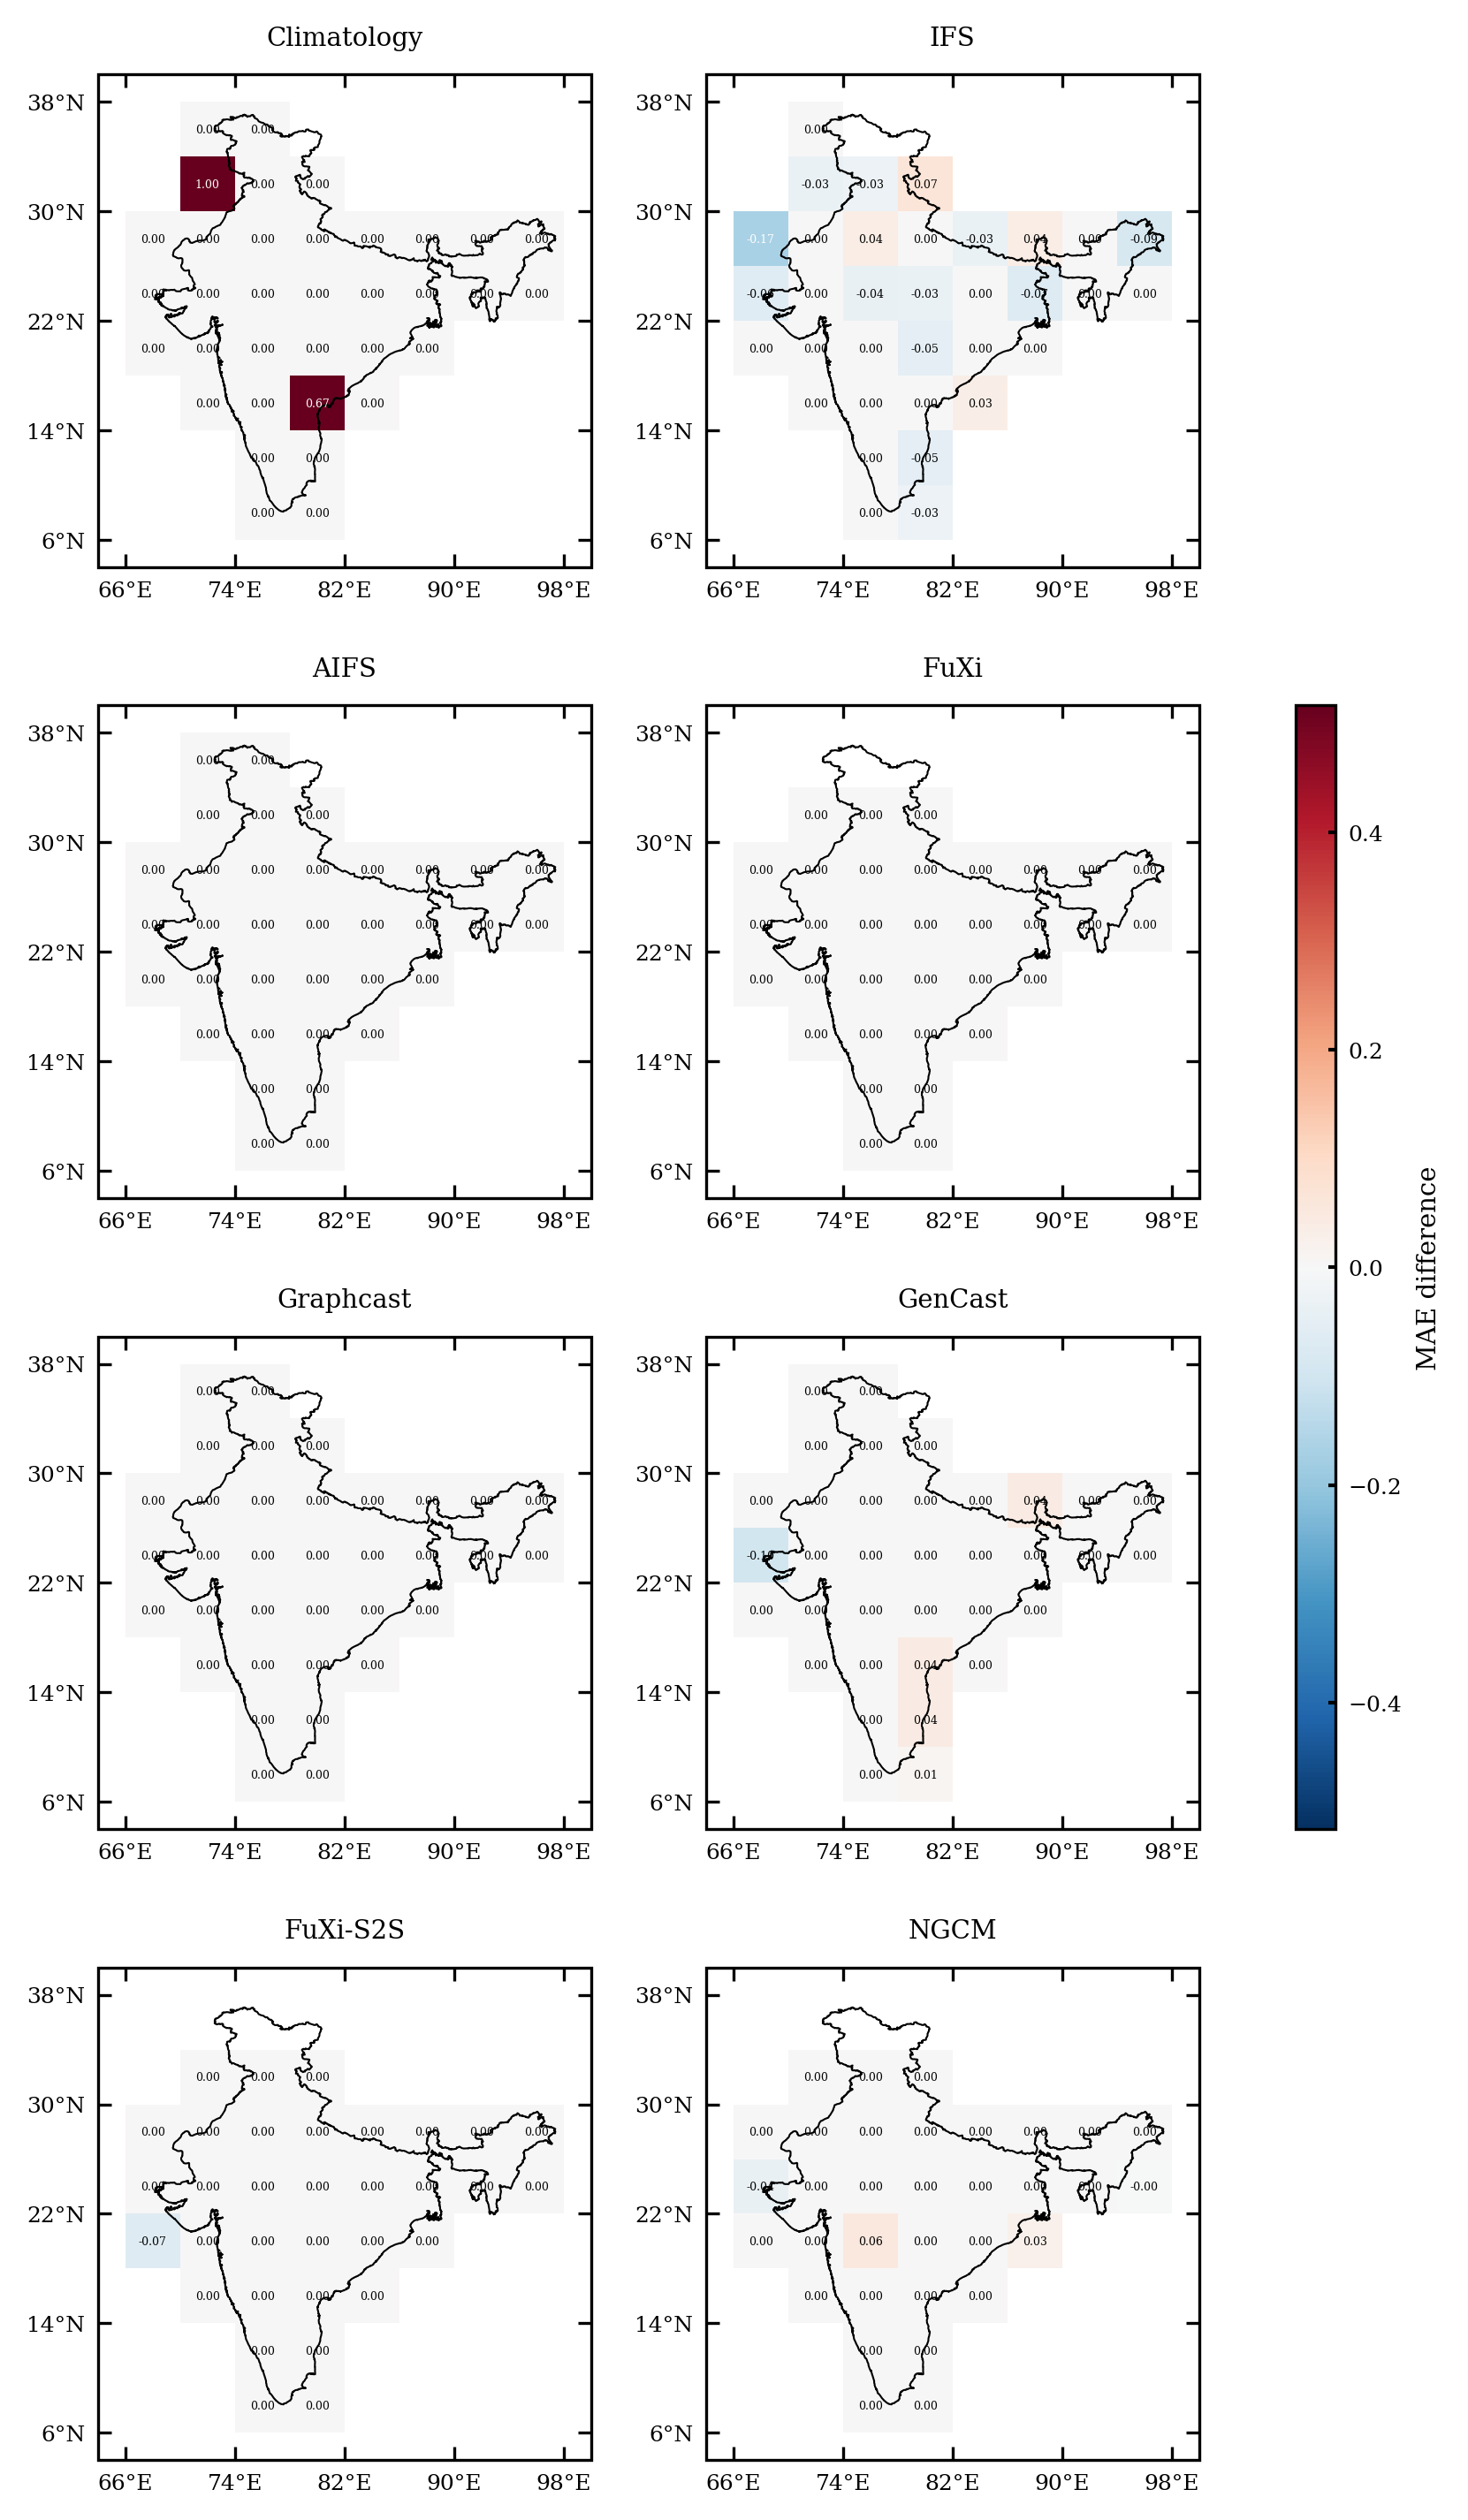

In [ ]:
spatial_30_diffs_mae_fig = create_8_panel_diff_figure(
    differences_fig_8_10_12,
    lon=lon,
    lat=lat,
    models=model_str,
    metric="mae"
)

Creating FAR diff figure...
Panel 1/8: far - Climatology
Panel 2/8: far - IFS
Panel 3/8: far - AIFS
Panel 4/8: far - FuXi
Panel 5/8: far - Graphcast
Panel 6/8: far - GenCast
Panel 7/8: far - FuXi-S2S
Panel 8/8: far - NGCM


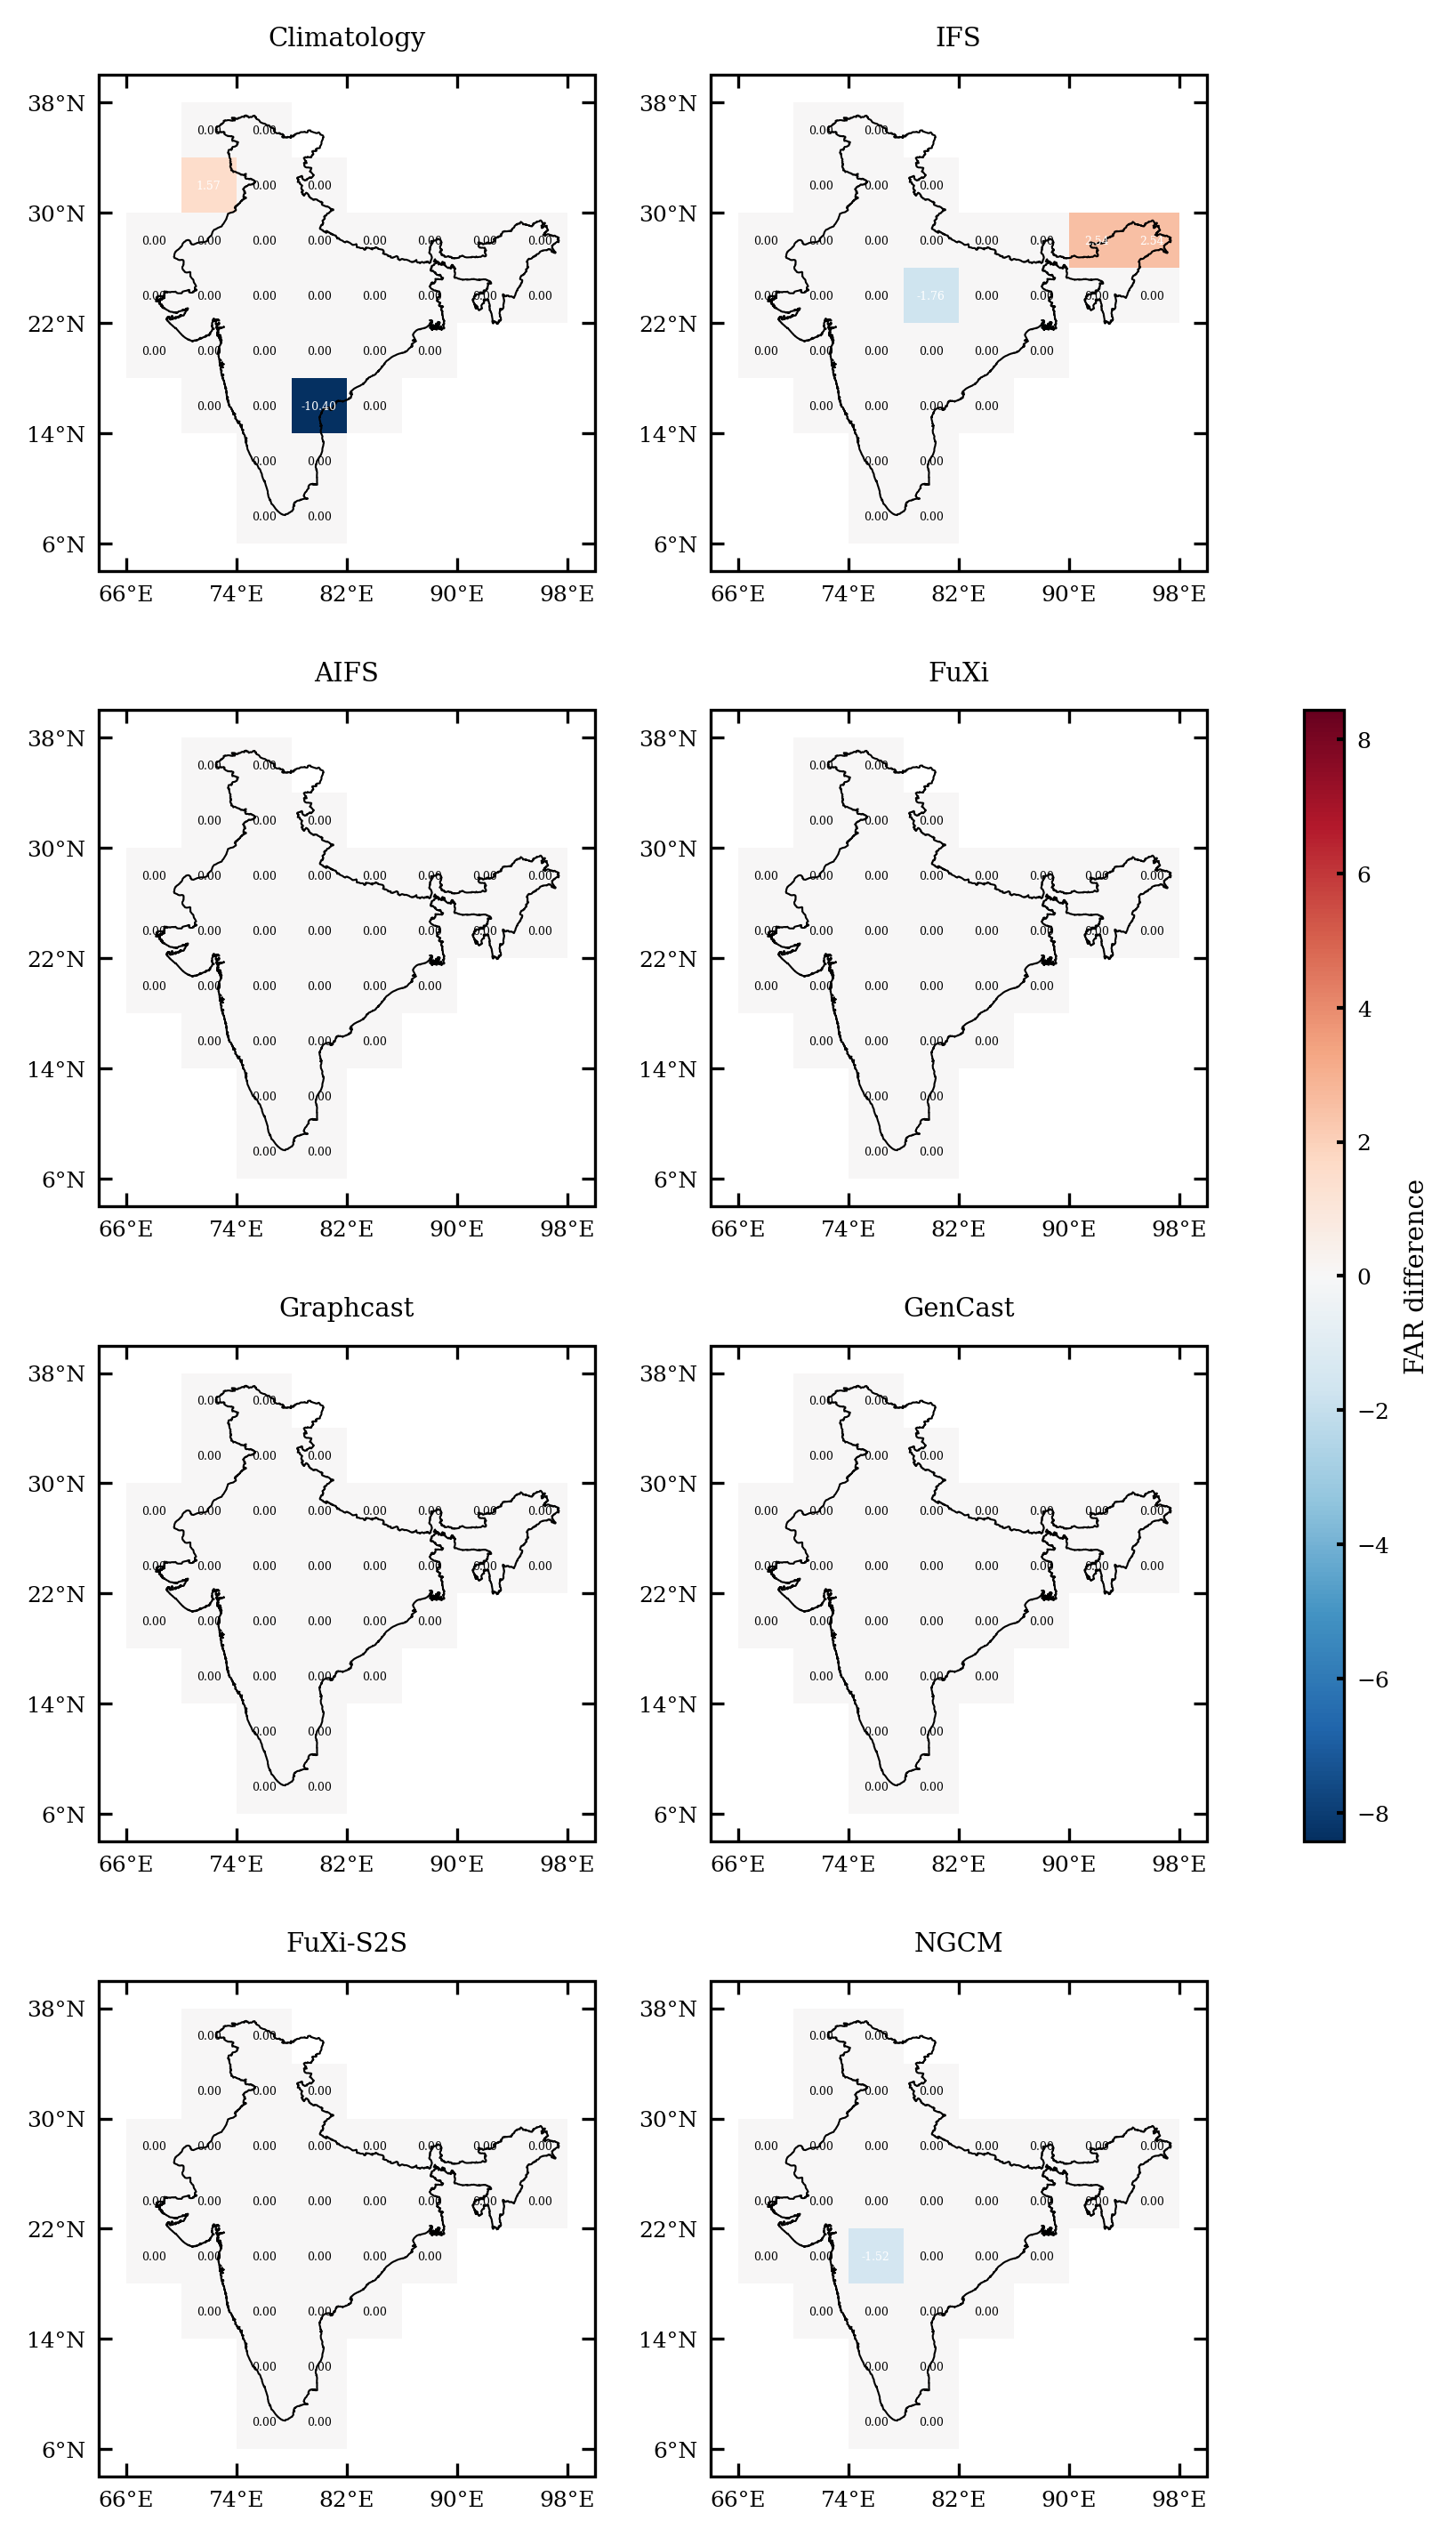

In [ ]:
spatial_15_diffs_far_fig = create_8_panel_diff_figure(
    differences_fig_7_9_11,
    lon=lon,
    lat=lat,
    models=model_str,
    metric="far"
)

Creating FAR diff figure...
Panel 1/8: far - Climatology
Panel 2/8: far - IFS
Panel 3/8: far - AIFS
Panel 4/8: far - FuXi
Panel 5/8: far - Graphcast
Panel 6/8: far - GenCast
Panel 7/8: far - FuXi-S2S
Panel 8/8: far - NGCM


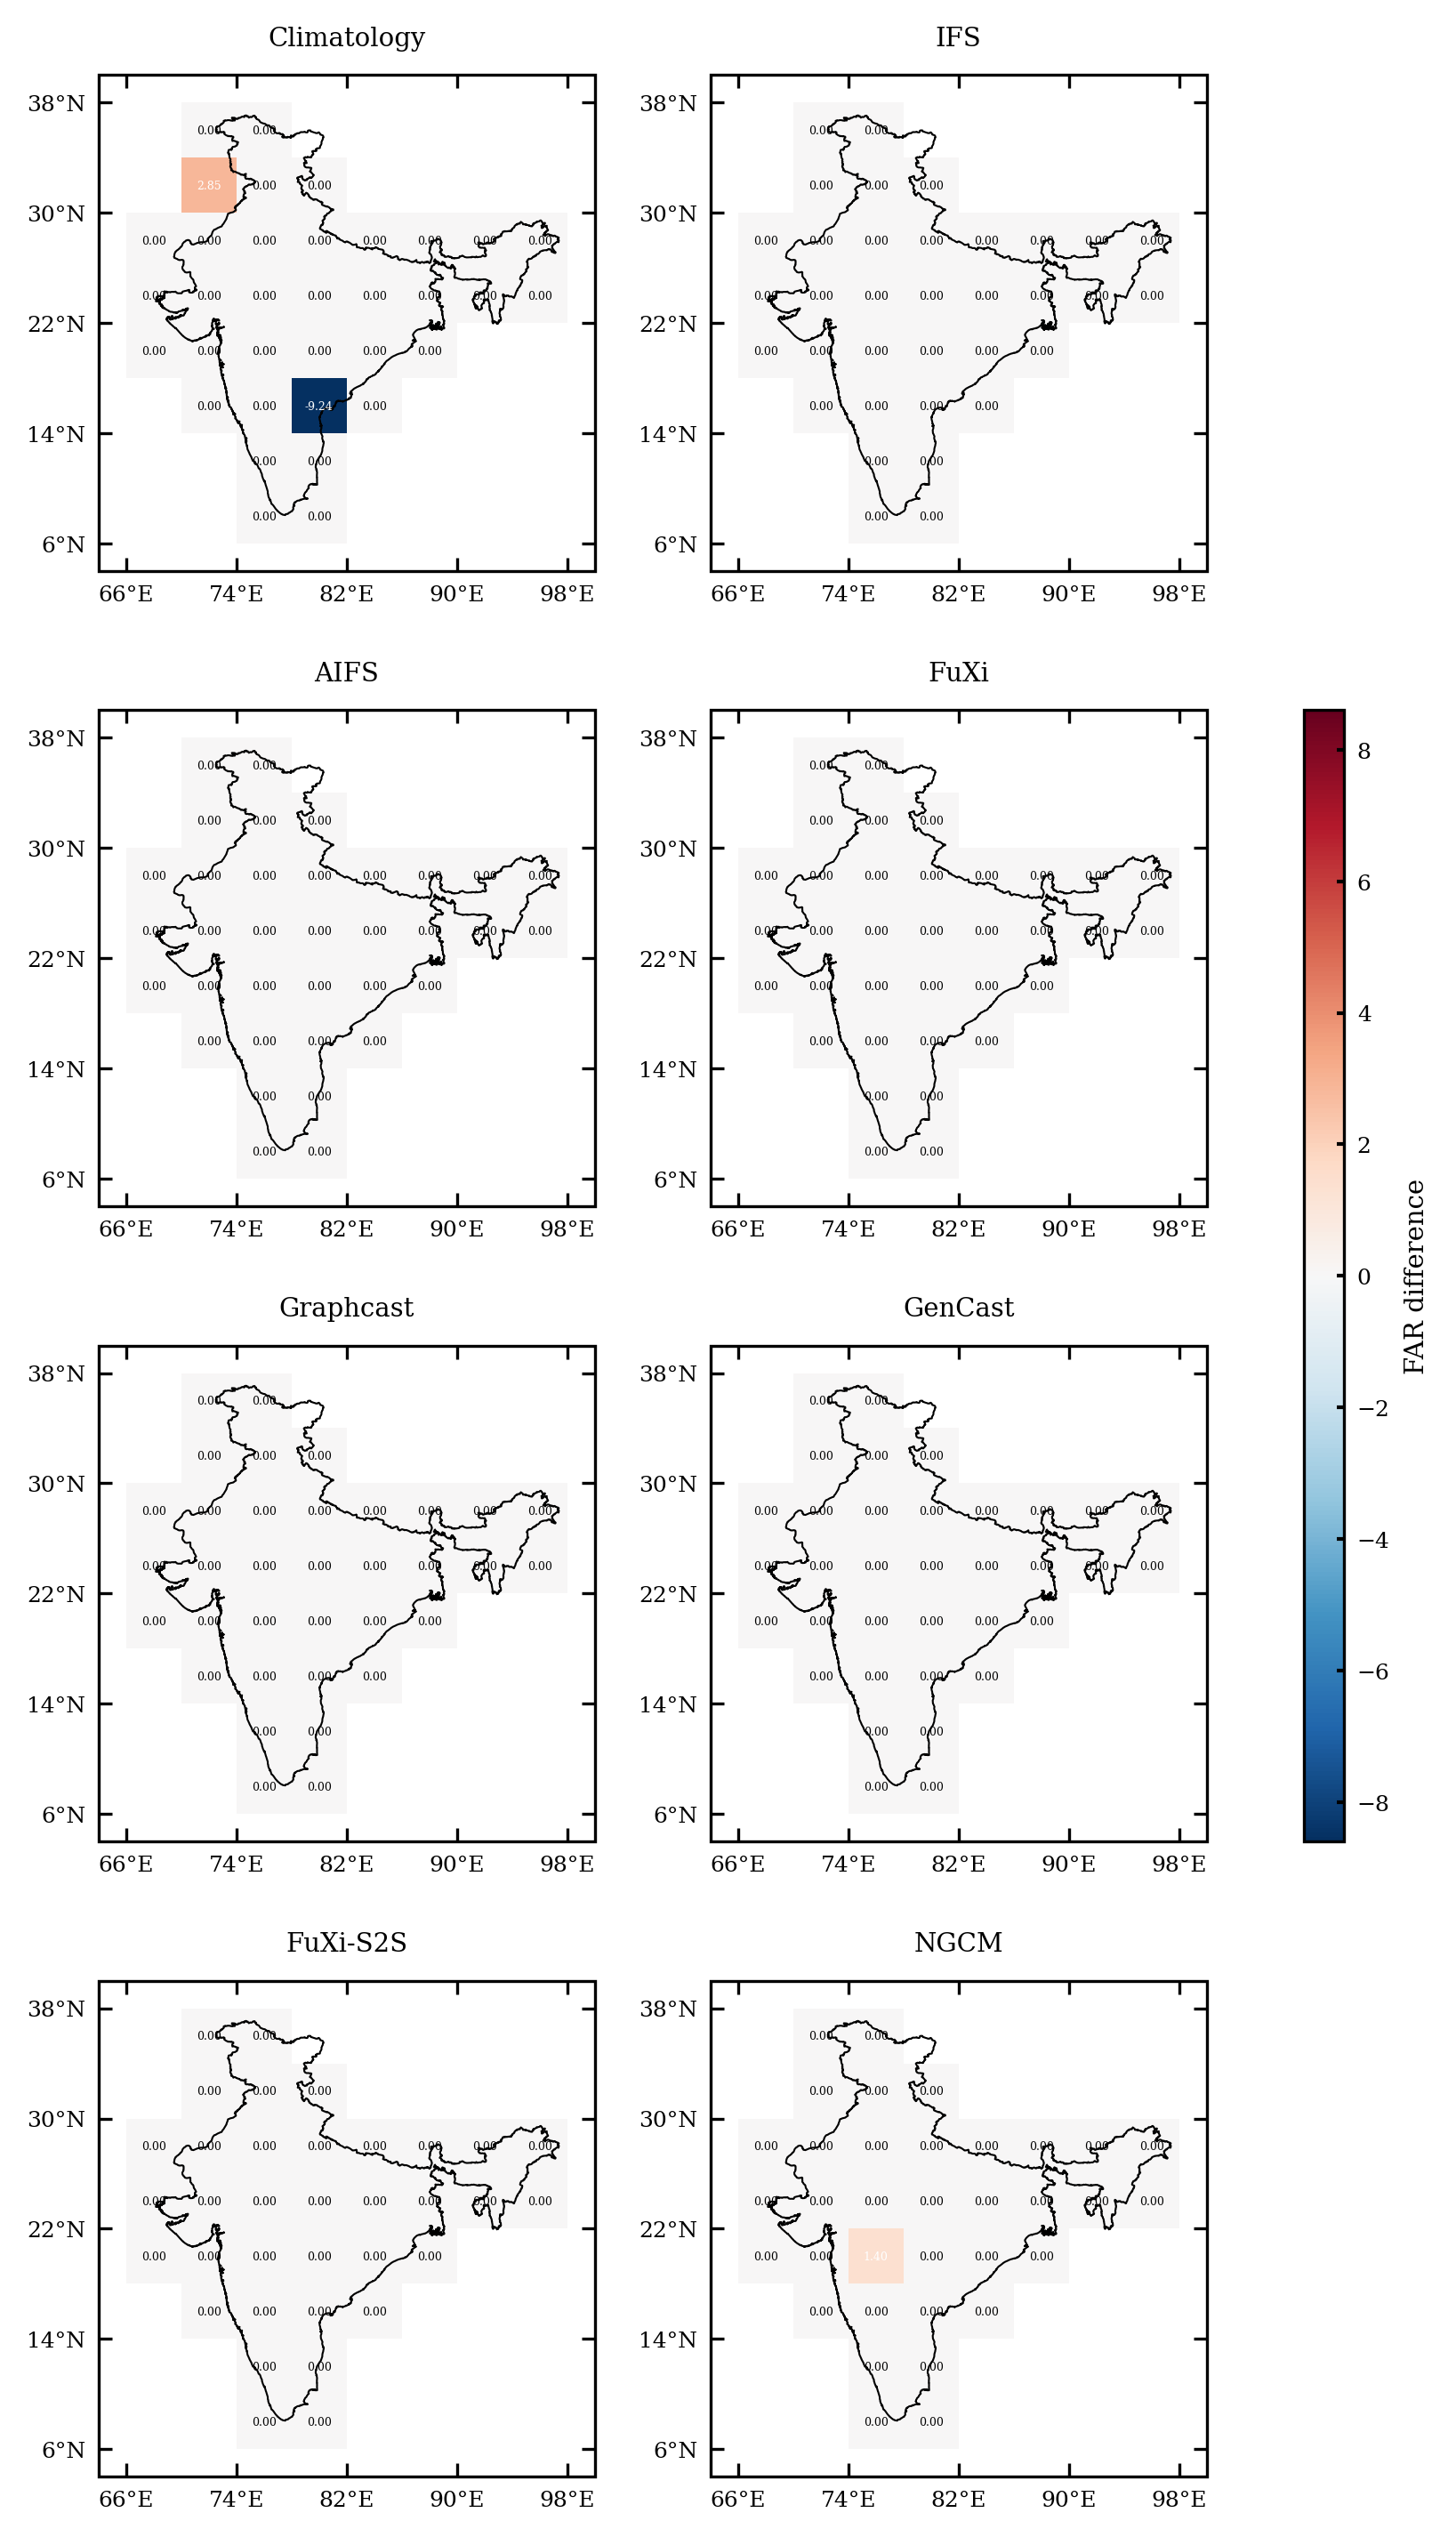

In [ ]:
spatial_30_diffs_far_fig = create_8_panel_diff_figure(
    differences_fig_8_10_12,
    lon=lon,
    lat=lat,
    models=model_str,
    metric="far"
)

Creating MR diff figure...
Panel 1/8: mr - Climatology
Panel 2/8: mr - IFS
Panel 3/8: mr - AIFS
Panel 4/8: mr - FuXi
Panel 5/8: mr - Graphcast
Panel 6/8: mr - GenCast
Panel 7/8: mr - FuXi-S2S
Panel 8/8: mr - NGCM


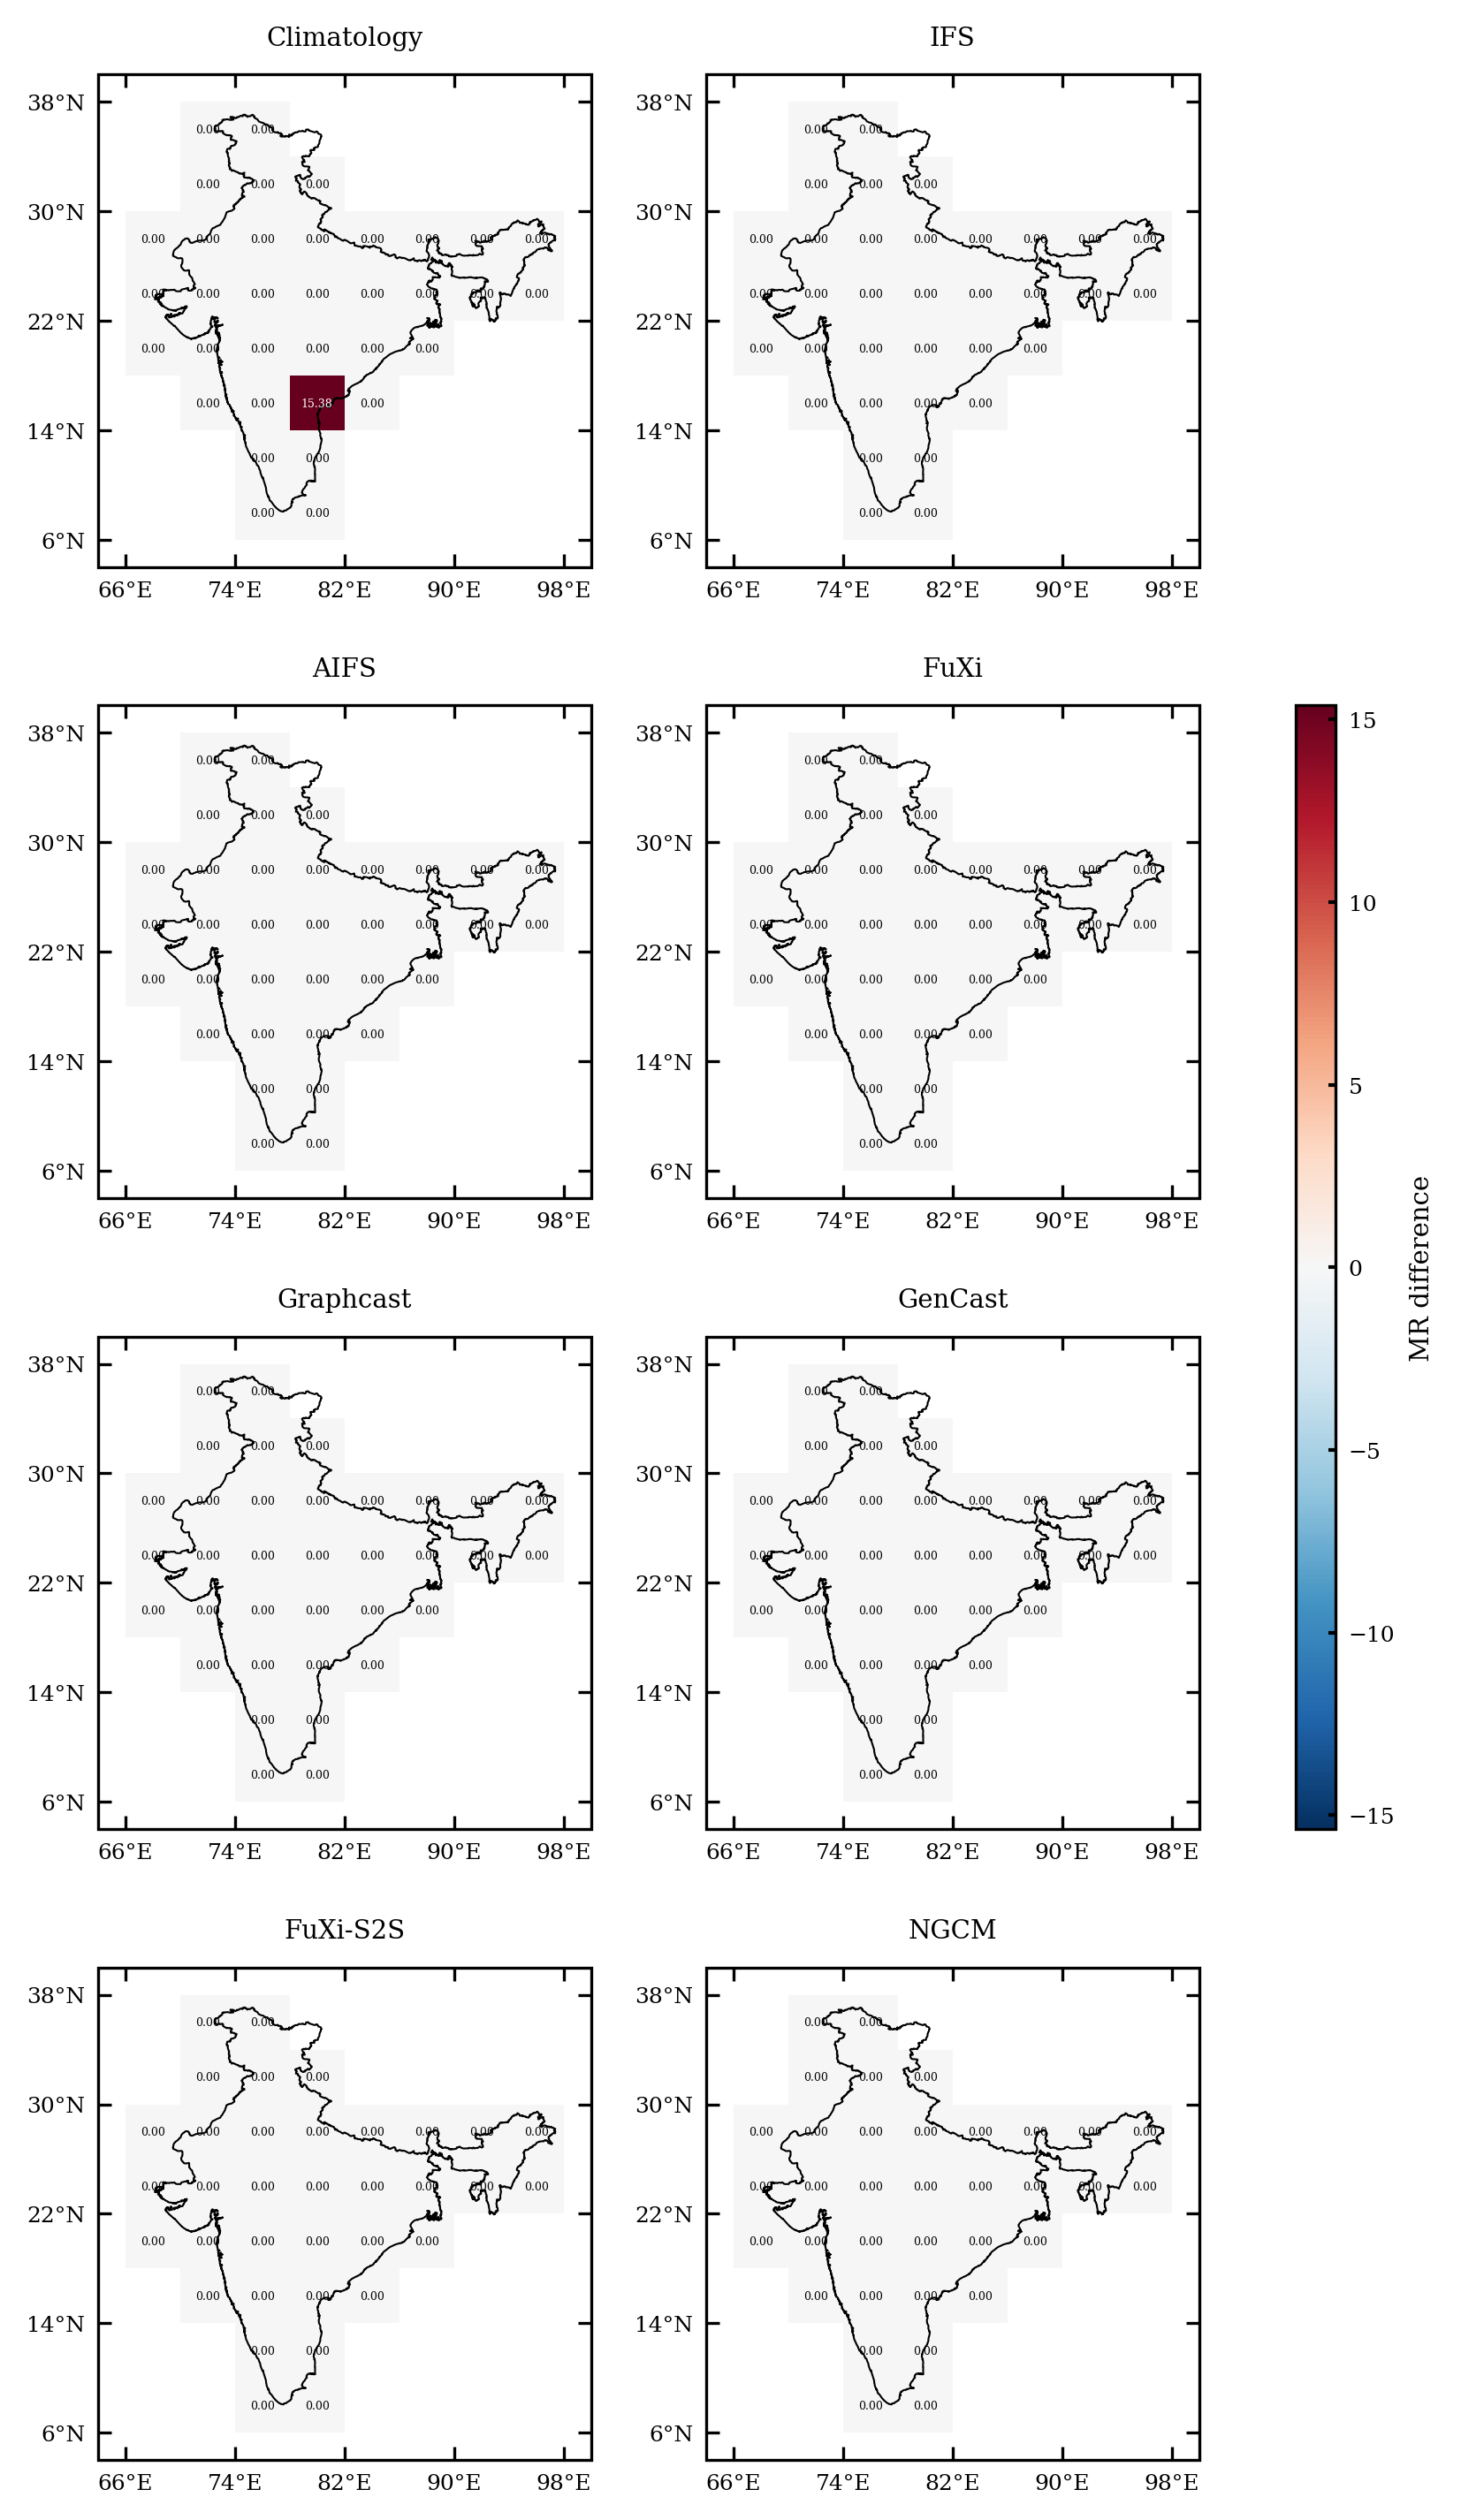

In [ ]:
spatial_15_diffs_mr_fig = create_8_panel_diff_figure(
    differences_fig_7_9_11,
    lon=lon,
    lat=lat,
    models=model_str,
    metric="mr"
)

Creating MR diff figure...
Panel 1/8: mr - Climatology
Panel 2/8: mr - IFS
Panel 3/8: mr - AIFS
Panel 4/8: mr - FuXi
Panel 5/8: mr - Graphcast
Panel 6/8: mr - GenCast
Panel 7/8: mr - FuXi-S2S
Panel 8/8: mr - NGCM


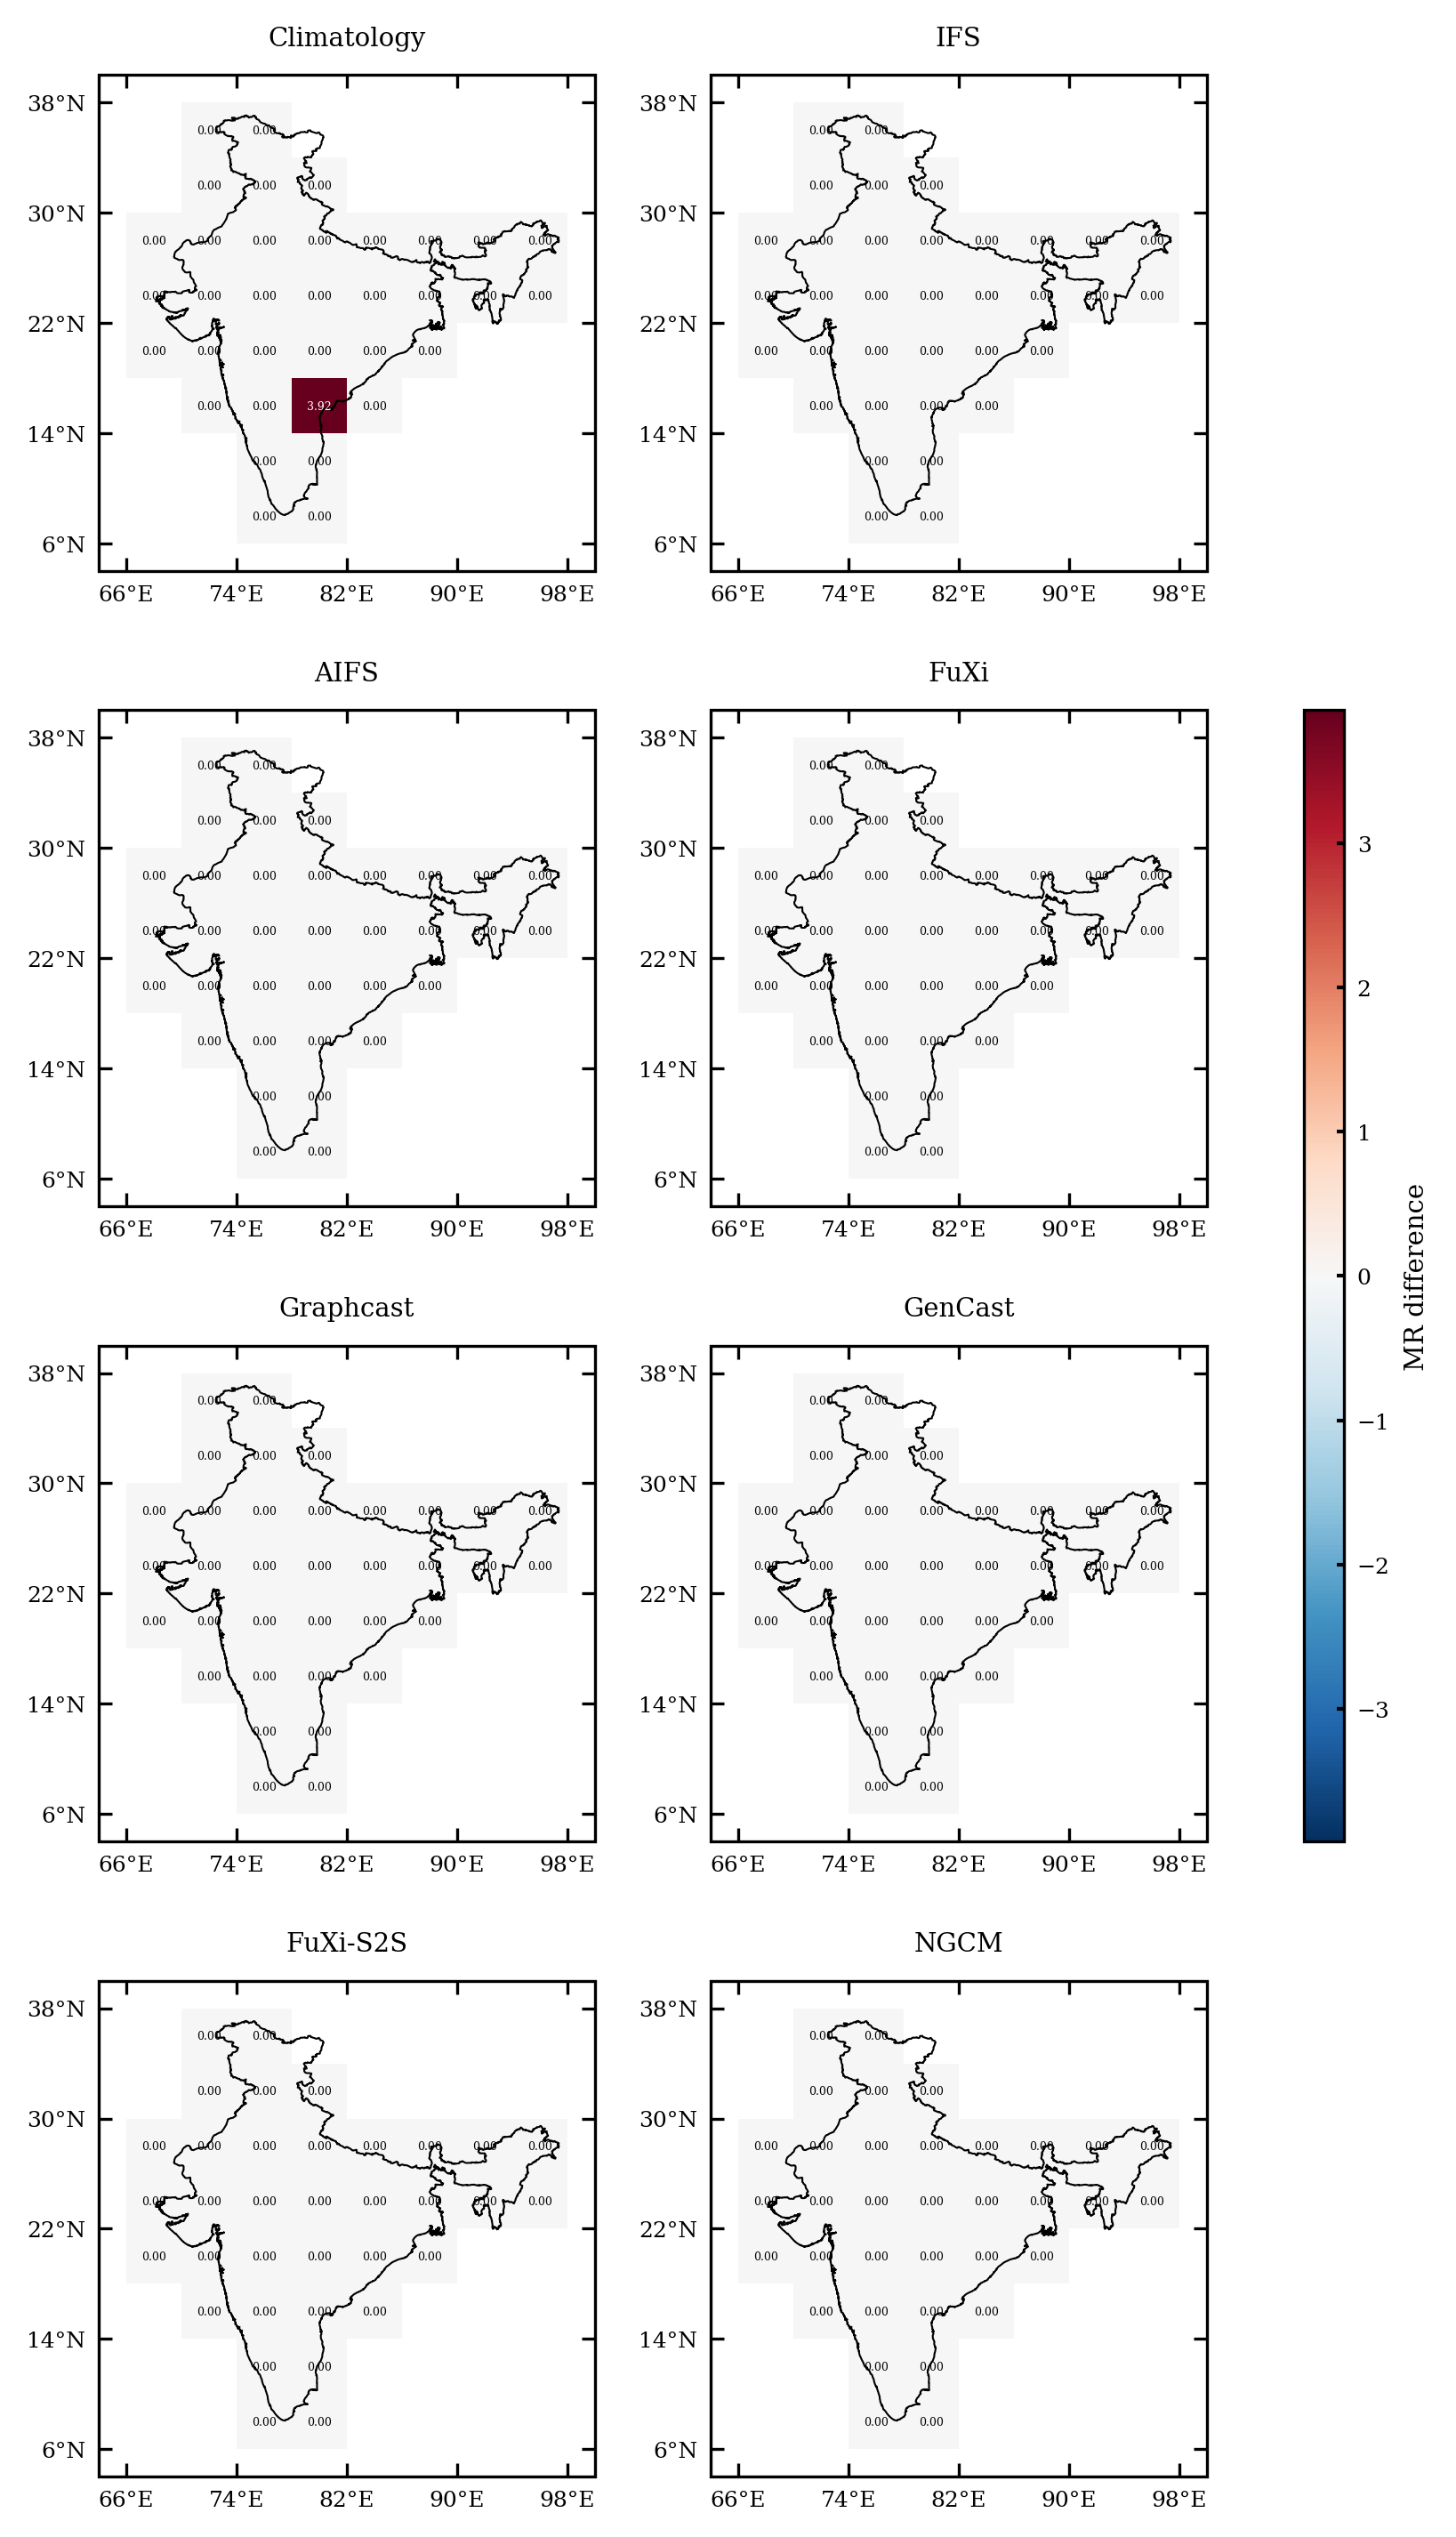

In [ ]:
spatial_30_diffs_mr_fig = create_8_panel_diff_figure(
    differences_fig_8_10_12,
    lon=lon,
    lat=lat,
    models=model_str,
    metric="mr"
)